In [1]:
import pandas as pd

file_path = 'df_prop_binario.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda,y_bin,classe_risco_qualificacao
0,5197734,1421.0,2,35,52403,0,2,1,1,1,...,0.0,0,0,0.0,0.0,0.000000,0.5,2,1,renda formal per capita (CNIS) > ½ SM
1,3623103,178.0,2,31,47907,0,2,1,1,1,...,0.0,0,0,0.0,0.0,0.500000,0.0,0,0,renda formal per capita (CNIS) ≤ ½ SM
2,1772091,253.0,2,26,10608,0,1,1,1,2,...,0.0,0,0,0.0,0.0,0.000000,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
3,7938174,276.0,2,52,17609,0,1,1,1,1,...,1.0,0,0,0.0,0.0,0.000000,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
4,5030351,5888.0,2,35,50308,0,3,1,1,1,...,0.0,0,0,0.0,0.0,0.333333,0.0,2,1,renda formal per capita (CNIS) > ½ SM


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 54 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   VL_RENDA_MEDIA_FAM            1000000 non-null  float64
 2   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 3   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 4   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 5   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 6   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 7   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 8   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 9   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 10  QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 11  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 12  CO_MATERIAL_DOMIC_FAM        

In [4]:
import pandas as pd

# ── 1) Presença do código 53 no df original ───────────────────────────────────
col = "CO_MUNIC_IBGE_2_FAM"

ufs_presentes = sorted(df[col].dropna().unique().astype(int).tolist())
print(f"UFs presentes no df original ({len(ufs_presentes)}):")
print(ufs_presentes)

ufs_esperadas = {
    11, 12, 13, 14, 15, 16, 17,
    21, 22, 23, 24, 25, 26, 27, 28, 29,
    31, 32, 33, 35,
    41, 42, 43,
    50, 51, 52, 53,
}
ufs_faltantes = ufs_esperadas - set(ufs_presentes)
print(f"\nUFs faltantes: {sorted(ufs_faltantes) if ufs_faltantes else 'Nenhuma — todas as 27 presentes'}")

# ── 2) Volume por UF ──────────────────────────────────────────────────────────
UF_SIGLA = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA",
    31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS",
    50: "MS", 51: "MT", 52: "GO", 53: "DF",
}

resumo = (
    df[col].value_counts()
    .rename_axis("codigo")
    .reset_index(name="N")
    .assign(
        codigo=lambda x: x["codigo"].astype(int),
        UF=lambda x: x["codigo"].map(UF_SIGLA).fillna("?"),
        pct=lambda x: (x["N"] / x["N"].sum() * 100).round(2),
    )
    .sort_values("codigo")
    [["codigo", "UF", "N", "pct"]]
    .reset_index(drop=True)
)
resumo["N"]   = resumo["N"].map("{:,}".format)
resumo["pct"] = resumo["pct"].map("{:.2f}%".format)

print(f"\nVolume por UF no df original (total: {len(df):,} linhas):")
display(resumo)

# ── 3) Se 53 existe mas com volume baixo ─────────────────────────────────────
n_df = (df[col] == 53).sum()
print(f"\nLinhas com código 53 (DF) no df original: {n_df:,}")

# ── 4) Rastrear se o filtro SQL removeu o DF ─────────────────────────────────
print("\nParâmetros de filtro usados na query:")
print(f"  munic2_ini = {munic2_ini if 'munic2_ini' in dir() else 'não definido'}")
print(f"  munic2_fim = {munic2_fim if 'munic2_fim' in dir() else 'não definido'}")
if 'munic2_ini' in dir() and 'munic2_fim' in dir():
    print(f"  53 dentro do intervalo [{munic2_ini}, {munic2_fim}]: {munic2_ini <= 53 <= munic2_fim}")

UFs presentes no df original (27):
[11, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 41, 42, 43, 50, 51, 52, 53]

UFs faltantes: Nenhuma — todas as 27 presentes

Volume por UF no df original (total: 1,000,000 linhas):


,codigo,UF,N,pct
0,11,RO,"8,743",0.87%
1,12,AC,"4,138",0.41%
2,13,AM,"16,662",1.67%
3,14,RR,"2,974",0.30%
4,15,PA,"35,697",3.57%
5,16,AP,"3,192",0.32%
6,17,TO,"9,433",0.94%
7,21,MA,"23,885",2.39%
8,22,PI,"16,612",1.66%
9,23,CE,"47,016",4.70%



Linhas com código 53 (DF) no df original: 12,307

Parâmetros de filtro usados na query:
  munic2_ini = não definido
  munic2_fim = não definido


In [5]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).any()

np.True_

In [6]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).sum()

np.int64(242)

In [7]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [8]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [9]:
df['y_bin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: y_bin
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


## Separação treino e teste

In [10]:
df["ID_FAM_ANON"].is_unique

True

In [11]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [12]:
colunas_excluir = [
    "classe_renda",
    "y_bin",
    "classe_risco_qualificacao",
    "VL_RENDA_MEDIA_FAM",
    "ID_FAM_ANON"
]

X = df.drop(columns=colunas_excluir)
y = df["y_bin"]


In [13]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [14]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1

## Análise de correlação das variáveis

In [15]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
    'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
    'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

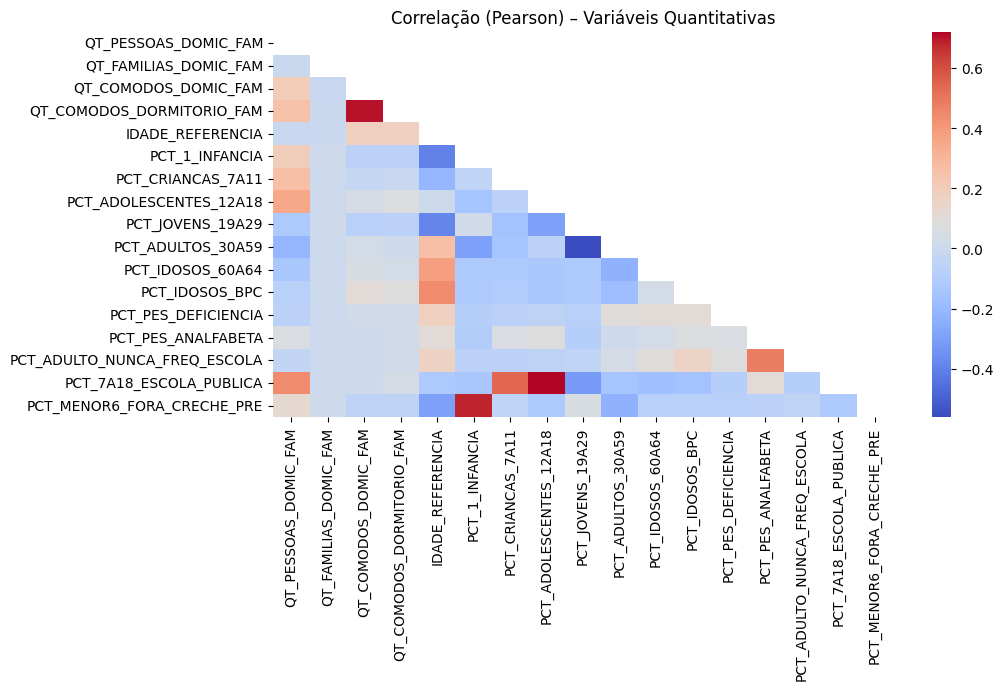

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = X[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [17]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.715935
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.698638
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.682823
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.564747
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.540172
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.483242
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.442998
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.439084
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.398539
61,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.388439


In [18]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [19]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


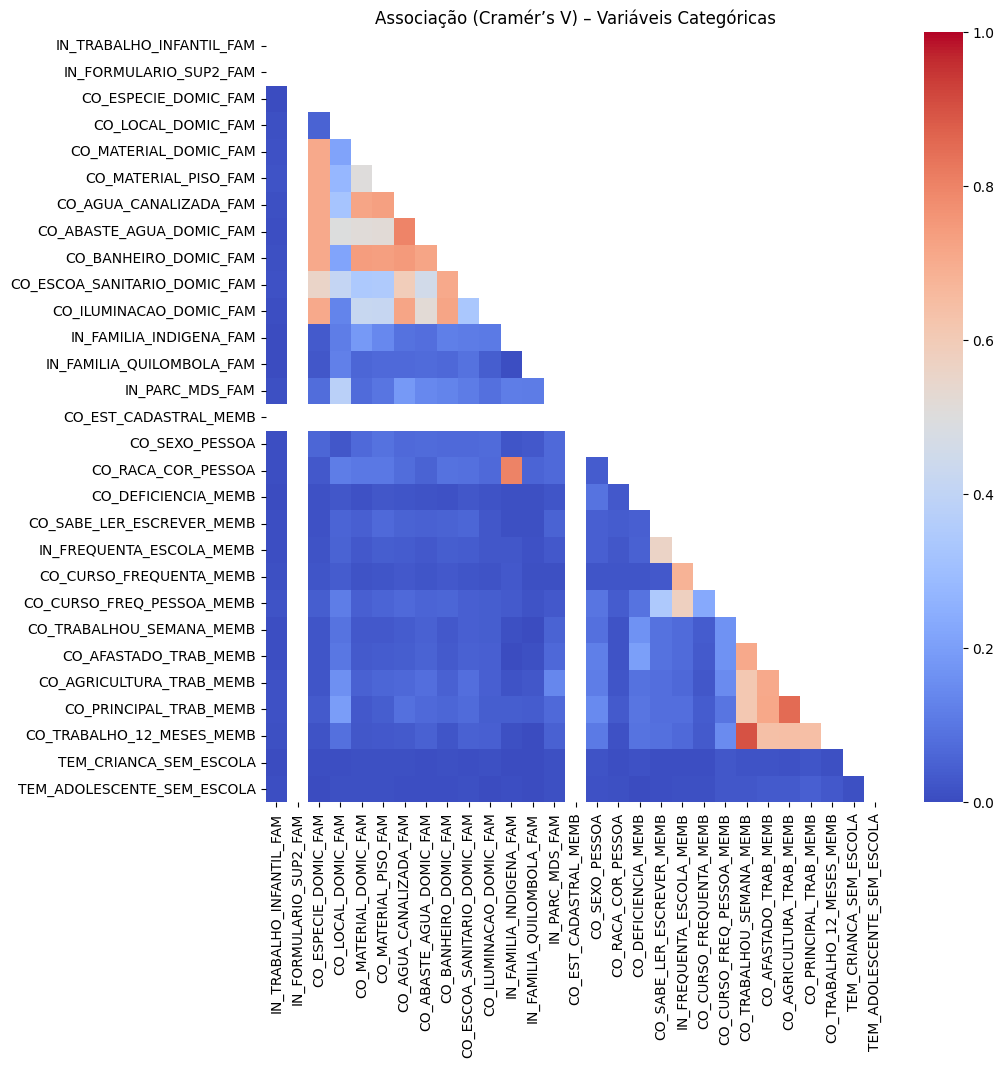

In [20]:
# Selecionar todas as categóricas
df_cat = X[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [21]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
333  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900383
341  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.852669
218   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.800995
120    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.796955
121    CO_AGUA_CANALIZADA_FAM      CO_BANHEIRO_DOMIC_FAM   0.746949
78      CO_MATERIAL_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.740447
100      CO_MATERIAL_PISO_FAM      CO_BANHEIRO_DOMIC_FAM   0.737158
98       CO_MATERIAL_PISO_FAM     CO_AGUA_CANALIZADA_FAM   0.730719
141  CO_ABASTE_AGUA_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.722457
76      CO_MATERIAL_DOMIC_FAM     CO_AGUA_CANALIZADA_FAM   0.721716


In [22]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
333  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900383
341  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.852669
218   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.800995


In [23]:
X = X.drop(columns=['CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM'])

In [24]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT

In [25]:
X.head()

,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,2,35,52403,0,2,1,1,1,5,2,...,0.500000,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.5
1,2,31,47907,0,2,1,1,1,5,2,...,0.500000,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.0
2,2,26,10608,0,1,1,1,2,4,1,...,0.000000,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.0
3,2,52,17609,0,1,1,1,1,2,1,...,0.000000,0.0,0.0,1.0,0,0,0.0,0.0,0.000000,0.0
4,2,35,50308,0,3,1,1,1,6,2,...,0.666667,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.0


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 46 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 1   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 2   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 3   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM       

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [27]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT

In [28]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 
    'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'QTD_PESSOAS', 'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']


In [29]:
# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'CO_LOCAL_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB']


In [30]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
   ("scale", MinMaxScaler()),
])

In [31]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [32]:
# Pipeline para binárias
pipeline_binary = "passthrough"

In [33]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [34]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [35]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [36]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [38]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM', 'QTD_PESSOAS',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
                                  'PCT_ADULTOS_30A59', 'PCT_IDOS...
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'IN_FREQUENTA_ESCOLA_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB',
                                  'CO_TRABALHO_12_MESES_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [39]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__QTD_PESSOAS,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,...,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,multicat__CO_TRABALHO_12_MESES_MEMB_-1,multicat__CO_TRABALHO_12_MESES_MEMB_1,multicat__CO_TRABALHO_12_MESES_MEMB_2,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.076923,0.010101,0.030928,0.021739,0.076923,0.233333,0.000000,0.0,0.5,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,36306.0
1,0.076923,0.010101,0.061856,0.032609,0.076923,0.344444,0.000000,0.0,0.5,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,35.0,3802.0
2,0.307692,0.010101,0.072165,0.032609,0.307692,0.244444,0.200000,0.0,0.4,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,6603.0
3,0.076923,0.010101,0.061856,0.032609,0.076923,0.233333,0.500000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,56700.0
4,0.153846,0.010101,0.072165,0.043478,0.153846,0.333333,0.333333,0.0,0.0,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0,4557.0


### Comparando diversos modelos

In [40]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 0) CONFIG DE TRIAGEM
# ------------------------------------------------------------
SEED = 42
THRESHOLD_TRIAGEM = 0.80  # ajuste depois conforme capacidade operacional
POS_LABEL = 1             # 1 = acima de 1/2 SM (potencialmente não elegível)


# ------------------------------------------------------------
# 1) MODELOS (ajustados para BINÁRIO)
# ------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"  # ajuda quando há desbalanceamento
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1200,          # mais árvores + taxa menor costuma ajudar
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
        # (opcional) scale_pos_weight pode ser ajustado se a classe 1 for rara
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False
        # (opcional) class_weights=[w0, w1] se necessário
    ),
}


# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (com métricas para TRIAGEM)
# ------------------------------------------------------------
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    # Predição padrão (threshold 0.5)
    y_pred_05 = pipe.predict(X_test).ravel()

    # Probabilidades (para AUC/PR-AUC e para threshold de triagem)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    # Predição para TRIAGEM (threshold configurável)
    if y_proba is not None:
        y_pred_t = (y_proba >= THRESHOLD_TRIAGEM).astype(int)
    else:
        y_pred_t = y_pred_05  # fallback

    # -------------------------
    # Métricas: padrão 0.5
    # -------------------------
    acc_05 = accuracy_score(y_test, y_pred_05)
    balacc_05 = balanced_accuracy_score(y_test, y_pred_05)

    prec_05 = precision_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    rec_05  = recall_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    f1_05   = f1_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)

    tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()

    # -------------------------
    # Métricas: TRIAGEM (threshold = THRESHOLD_TRIAGEM)
    # -------------------------
    acc_t = accuracy_score(y_test, y_pred_t)
    balacc_t = balanced_accuracy_score(y_test, y_pred_t)

    prec_t = precision_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    f1_t   = f1_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)

    tnt, fpt, fnt, tpt = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()

    # -------------------------
    # AUC / PR-AUC (se houver proba)
    # -------------------------
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC (muito útil p/ triagem)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # "Taxa de convocação" no teste (volume relativo gerado pela regra)
    convoc_rate = float(np.mean(y_pred_t == 1))

    results.append({
        "modelo": name,

        # Ranking mais aderente ao objetivo de triagem
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,

        # Métricas com threshold padrão
        "acc@0.50": acc_05,
        "bal_acc@0.50": balacc_05,
        "prec_pos@0.50": prec_05,
        "rec_pos@0.50": rec_05,
        "f1_pos@0.50": f1_05,
        "tp@0.50": tp05, "fp@0.50": fp05, "fn@0.50": fn05, "tn@0.50": tn05,

        # Métricas para a regra operacional de triagem
        f"acc@{THRESHOLD_TRIAGEM:.2f}": acc_t,
        f"bal_acc@{THRESHOLD_TRIAGEM:.2f}": balacc_t,
        f"prec_pos@{THRESHOLD_TRIAGEM:.2f}": prec_t,
        f"rec_pos@{THRESHOLD_TRIAGEM:.2f}": rec_t,
        f"f1_pos@{THRESHOLD_TRIAGEM:.2f}": f1_t,
        f"tp@{THRESHOLD_TRIAGEM:.2f}": tpt, f"fp@{THRESHOLD_TRIAGEM:.2f}": fpt,
        f"fn@{THRESHOLD_TRIAGEM:.2f}": fnt, f"tn@{THRESHOLD_TRIAGEM:.2f}": tnt,

        # volume gerado
        f"taxa_convocacao@{THRESHOLD_TRIAGEM:.2f}": convoc_rate,
    })


# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = (
    pd.DataFrame(results)
      .sort_values(["pr_auc", "roc_auc"], ascending=False)
      .reset_index(drop=True)
)

df_results



Treinando modelo: LogisticRegression

Treinando modelo: RandomForest

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,pr_auc,roc_auc,acc@0.50,bal_acc@0.50,prec_pos@0.50,rec_pos@0.50,f1_pos@0.50,tp@0.50,fp@0.50,...,acc@0.80,bal_acc@0.80,prec_pos@0.80,rec_pos@0.80,f1_pos@0.80,tp@0.80,fp@0.80,fn@0.80,tn@0.80,taxa_convocacao@0.80
0,XGBoost,0.846210,0.825609,0.751050,0.740437,0.748334,0.833392,0.788576,92854,31227,...,0.620045,0.653368,0.892506,0.361498,0.514574,40277,4851,71140,83732,0.225640
1,CatBoost,0.844126,0.823719,0.749880,0.739380,0.747834,0.831345,0.787382,92626,31233,...,0.613800,0.647992,0.892993,0.348511,0.501356,38830,4653,72587,83930,0.217415
2,HistGradientBoosting,0.842522,0.821884,0.747815,0.737002,0.745187,0.831713,0.786076,92667,31687,...,0.611810,0.646238,0.892514,0.344687,0.497313,38404,4625,73013,83958,0.215145
3,RandomForest,0.816144,0.799637,0.731275,0.722696,0.740072,0.797841,0.767871,88893,31221,...,0.616470,0.647408,0.852976,0.376424,0.522337,41940,7229,69477,81354,0.245845
4,LogisticRegression,0.811865,0.792850,0.725835,0.719133,0.742342,0.777835,0.759674,86664,30080,...,0.602385,0.635702,0.856485,0.343879,0.490730,38314,6420,73103,82163,0.223670


In [43]:
import pandas as pd

# ── Colunas de interesse ──────────────────────────────────────────────────────
cols_050 = {
    "prec_pos@0.50"  : "precision_pos",
    "rec_pos@0.50"   : "recall_pos",
    "f1_pos@0.50"    : "f1_pos",
    "tp@0.50"        : "tp",
    "fp@0.50"        : "fp",
    "fn@0.50"        : "fn",
    "tn@0.50"        : "tn",
}
cols_080 = {
    "prec_pos@0.80"  : "precision_pos",
    "rec_pos@0.80"   : "recall_pos",
    "f1_pos@0.80"    : "f1_pos",
    "tp@0.80"        : "tp",
    "fp@0.80"        : "fp",
    "fn@0.80"        : "fn",
    "tn@0.80"        : "tn",
    "taxa_convocacao@0.80": "taxa_convocacao",
}

# ── Montar tabela comparativa ─────────────────────────────────────────────────
linhas = []
for _, row in df_results.iterrows():
    for thr, cols in [("0.50", cols_050), ("0.80", cols_080)]:
        linha = {
            "modelo"   : row["modelo"],
            "threshold": float(thr),
            "pr_auc"   : row.get("pr_auc",  None),   # ← adicionado
            "roc_auc"  : row.get("roc_auc", None),   # ← adicionado
        }
        for col_orig, col_novo in cols.items():
            linha[col_novo] = row.get(col_orig, None)
        if thr == "0.50":
            total = linha["tp"] + linha["fp"] + linha["fn"] + linha["tn"]
            linha["taxa_convocacao"] = (linha["tp"] + linha["fp"]) / total if total > 0 else 0
        linhas.append(linha)

tab = pd.DataFrame(linhas)

# ── Ordenar: threshold 0.80 primeiro, depois 0.50 ────────────────────────────
tab = tab.sort_values(
    ["threshold", "precision_pos"],
    ascending=[False, False]
).reset_index(drop=True)

# ── Tabela completa ───────────────────────────────────────────────────────────
print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===\n")
display(tab)

# ── Tabela de triagem (threshold=0.80 apenas) ─────────────────────────────────
print("\n=== Tabela de triagem (threshold=0.80) ===\n")
tab_triagem = (
    tab[tab["threshold"] == 0.80]
    .sort_values("recall_pos", ascending=False)
    .reset_index(drop=True)
)
display(
    tab_triagem.style
    .format({
        "pr_auc"         : "{:.4f}",
        "roc_auc"        : "{:.4f}",
        "precision_pos"  : "{:.4f}",
        "recall_pos"     : "{:.4f}",
        "f1_pos"         : "{:.4f}",
        "tp"             : "{:,.0f}",
        "fp"             : "{:,.0f}",
        "fn"             : "{:,.0f}",
        "tn"             : "{:,.0f}",
        "taxa_convocacao": "{:.4f}",
    })
    .highlight_max(
        subset=["pr_auc", "roc_auc", "precision_pos", "recall_pos", "f1_pos"],
        color="#c6efce"
    )
    .highlight_min(subset=["taxa_convocacao"], color="#ffeb9c")
    .set_properties(**{"text-align": "center", "padding": "6px 12px"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align", "center"),
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold")
        ]},
    ])
)


=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===



,modelo,threshold,pr_auc,roc_auc,precision_pos,recall_pos,f1_pos,tp,fp,fn,tn,taxa_convocacao
0,CatBoost,0.8,0.844126,0.823719,0.892993,0.348511,0.501356,38830,4653,72587,83930,0.217415
1,HistGradientBoosting,0.8,0.842522,0.821884,0.892514,0.344687,0.497313,38404,4625,73013,83958,0.215145
2,XGBoost,0.8,0.846210,0.825609,0.892506,0.361498,0.514574,40277,4851,71140,83732,0.225640
3,LogisticRegression,0.8,0.811865,0.792850,0.856485,0.343879,0.490730,38314,6420,73103,82163,0.223670
4,RandomForest,0.8,0.816144,0.799637,0.852976,0.376424,0.522337,41940,7229,69477,81354,0.245845
5,XGBoost,0.5,0.846210,0.825609,0.748334,0.833392,0.788576,92854,31227,18563,57356,0.620405
6,CatBoost,0.5,0.844126,0.823719,0.747834,0.831345,0.787382,92626,31233,18791,57350,0.619295
7,HistGradientBoosting,0.5,0.842522,0.821884,0.745187,0.831713,0.786076,92667,31687,18750,56896,0.621770
8,LogisticRegression,0.5,0.811865,0.792850,0.742342,0.777835,0.759674,86664,30080,24753,58503,0.583720
9,RandomForest,0.5,0.816144,0.799637,0.740072,0.797841,0.767871,88893,31221,22524,57362,0.600570



=== Tabela de triagem (threshold=0.80) ===



,modelo,threshold,pr_auc,roc_auc,precision_pos,recall_pos,f1_pos,tp,fp,fn,tn,taxa_convocacao
0,RandomForest,0.800000,0.8161,0.7996,0.8530,0.3764,0.5223,"41,940","7,229","69,477","81,354",0.2458
1,XGBoost,0.800000,0.8462,0.8256,0.8925,0.3615,0.5146,"40,277","4,851","71,140","83,732",0.2256
2,CatBoost,0.800000,0.8441,0.8237,0.8930,0.3485,0.5014,"38,830","4,653","72,587","83,930",0.2174
3,HistGradientBoosting,0.800000,0.8425,0.8219,0.8925,0.3447,0.4973,"38,404","4,625","73,013","83,958",0.2151
4,LogisticRegression,0.800000,0.8119,0.7929,0.8565,0.3439,0.4907,"38,314","6,420","73,103","82,163",0.2237


In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

POS_LABEL = 1                  # 1 = acima de 1/2 SM
THRESHOLDS = [0.50, 0.80]       # padrão e triagem

rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]

    # Probabilidades para usar thresholds
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    for thr in THRESHOLDS:
        if y_proba is None:
            # fallback: usa predict padrão (equivalente a 0.5)
            if thr != 0.50:
                continue
            y_pred = pipe.predict(X_test).ravel()
        else:
            y_pred = (y_proba >= thr).astype(int)

        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # guarda resumo (inclui taxa de convocação)
        rows.append({
            "modelo": nome,
            "threshold": thr,
            "precision_pos": rep["1"]["precision"],
            "recall_pos": rep["1"]["recall"],
            "f1_pos": rep["1"]["f1-score"],
            "support_pos": rep["1"]["support"],
            "precision_neg": rep["0"]["precision"],
            "recall_neg": rep["0"]["recall"],
            "f1_neg": rep["0"]["f1-score"],
            "accuracy": rep["accuracy"],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "taxa_convocacao": float((y_pred == 1).mean())
        })

df_thr = pd.DataFrame(rows).sort_values(["threshold", "f1_pos", "recall_pos"], ascending=False)

print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===")
display(df_thr)

# Se quiser uma tabela “apenas triagem” (thr=0.80), já pronta:
df_triagem = (
    df_thr[df_thr["threshold"] == 0.80]
    .sort_values(["precision_pos", "recall_pos"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Tabela de triagem (threshold=0.80) ===")
display(df_triagem)



=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
1,XGBoost,0.8,0.892506,0.361498,0.514574,111417.0,0.540653,0.945238,0.687864,0.620045,40277,4851,71140,83732,0.225640
5,CatBoost,0.8,0.892993,0.348511,0.501356,111417.0,0.536236,0.947473,0.684863,0.613800,38830,4653,72587,83930,0.217415
3,HistGradientBoosting,0.8,0.892514,0.344687,0.497313,111417.0,0.534863,0.947789,0.683825,0.611810,38404,4625,73013,83958,0.215145
0,XGBoost,0.5,0.748334,0.833392,0.788576,111417.0,0.755489,0.647483,0.697329,0.751050,92854,31227,18563,57356,0.620405
4,CatBoost,0.5,0.747834,0.831345,0.787382,111417.0,0.753208,0.647415,0.696316,0.749880,92626,31233,18791,57350,0.619295
2,HistGradientBoosting,0.5,0.745187,0.831713,0.786076,111417.0,0.752135,0.642290,0.692886,0.747815,92667,31687,18750,56896,0.621770



=== Tabela de triagem (threshold=0.80) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
0,CatBoost,0.8,0.892993,0.348511,0.501356,111417.0,0.536236,0.947473,0.684863,0.613800,38830,4653,72587,83930,0.217415
1,HistGradientBoosting,0.8,0.892514,0.344687,0.497313,111417.0,0.534863,0.947789,0.683825,0.611810,38404,4625,73013,83958,0.215145
2,XGBoost,0.8,0.892506,0.361498,0.514574,111417.0,0.540653,0.945238,0.687864,0.620045,40277,4851,71140,83732,0.225640


#### Fator para a escolha do modelo para o problema específico
##### Dado que o modelo será aplicado na base de renda informal, onde a incerteza já é estruturalmente maior, a diferença de precisão entre os modelos é pequena (~0,1pp). O XGBoost oferece melhor recall sem sacrifício relevante de precisão, importante quando o objetivo é qualificação cadastral uma escala maior.

# Pipeline processamento + Modelo (XGBoost)

In [45]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from xgboost import XGBClassifier

class XGBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_pos=0.80, random_state=42):
        self.threshold_pos = threshold_pos
        self.random_state = random_state
        self.model = XGBClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=self.random_state,  # ← usa o parâmetro, não hardcoded
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba_pos = self.model.predict_proba(X)[:, 1]
        return (proba_pos >= self.threshold_pos).astype(int)



In [46]:
from sklearn.pipeline import Pipeline

pipeline_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBoostComThreshold(threshold_pos=0.80))
])

pipeline_final.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'QTD_PESSOAS',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11',
                                                   'PCT_ADOLESCENTES_12A18',
                                                   'PCT_JOVENS_19A29'...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'IN_FREQUENTA_ESCOLA_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

## Avaliação completa do Modelo

=== Avaliação no threshold = 0.80 ===
Acurácia            : 0.6200
Precisão (classe 1) : 0.8925
Revocação (classe 1): 0.3615
F1 (classe 1)       : 0.5146
Taxa de convocação  : 0.2256

Matriz de confusão (valores absolutos):
               Pred ≤ 1/2 SM  Pred > 1/2 SM
Real ≤ 1/2 SM          83732           4851
Real > 1/2 SM          71140          40277


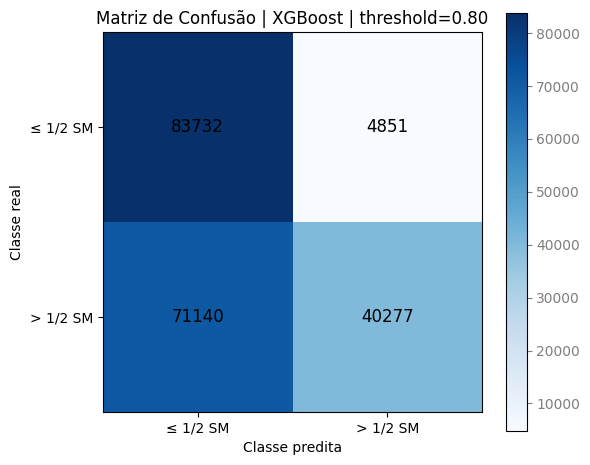

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
THRESHOLD = 0.80  

AZUL = "#1f77b4"
CINZA = "#7f7f7f"

# ------------------------------------------------------------
# 1) PREDIÇÕES NO THRESHOLD DEFINIDO
# ------------------------------------------------------------
# Probabilidade da classe positiva (1 = acima de 1/2 SM)
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Predição binária com threshold
y_pred = (proba_pos >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 2) MÉTRICAS NUMÉRICAS
# ------------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"=== Avaliação no threshold = {THRESHOLD:.2f} ===")
print(f"Acurácia            : {acc:.4f}")
print(f"Precisão (classe 1) : {prec:.4f}")
print(f"Revocação (classe 1): {rec:.4f}")
print(f"F1 (classe 1)       : {f1:.4f}")
print(f"Taxa de convocação  : {(y_pred == 1).mean():.4f}")

print("\nMatriz de confusão (valores absolutos):")
print(pd.DataFrame(
    cm,
    index=["Real ≤ 1/2 SM", "Real > 1/2 SM"],
    columns=["Pred ≤ 1/2 SM", "Pred > 1/2 SM"]
))

# ------------------------------------------------------------
# 3) PLOT DA MATRIZ DE CONFUSÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title(f"Matriz de Confusão | XGBoost | threshold={THRESHOLD:.2f}")
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["≤ 1/2 SM", "> 1/2 SM"])
ax.set_yticklabels(["≤ 1/2 SM", "> 1/2 SM"])

# Anotações dentro das células
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, int(val), ha="center", va="center", fontsize=12)

# Barra de cor (cinza discreto)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(color=CINZA)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=CINZA)

plt.tight_layout()
plt.show()



ROC-AUC: 0.8256


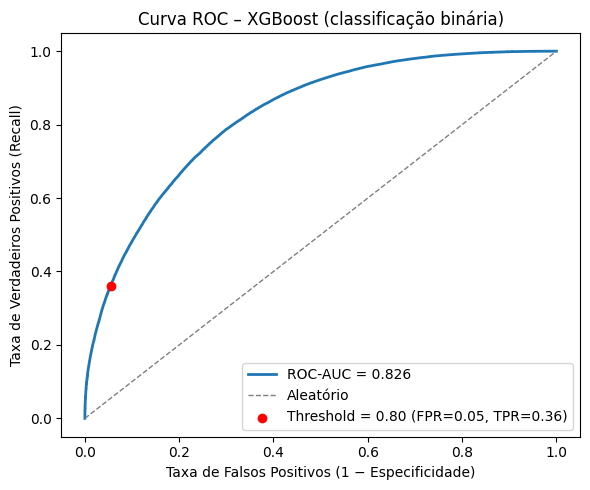

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
VERM = "red"

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA ROC E AUC
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, proba_pos)
roc_auc = roc_auc_score(y_test, proba_pos)
print(f"ROC-AUC: {roc_auc:.4f}")

# Ponto correspondente ao threshold 0.80
idx_thr = np.argmin(np.abs(thresholds - 0.80))
fpr_thr = fpr[idx_thr]
tpr_thr = tpr[idx_thr]

# ------------------------------------------------------------
# 3) PLOT DA CURVA ROC
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")

# Linha de referência (classificador aleatório)
ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1, label="Aleatório")

# Ponto do threshold 0.80
ax.scatter(fpr_thr, tpr_thr, color=VERM, zorder=5,
           label=f"Threshold = 0.80 (FPR={fpr_thr:.2f}, TPR={tpr_thr:.2f})")

ax.set_title("Curva ROC – XGBoost (classificação binária)")
ax.set_xlabel("Taxa de Falsos Positivos (1 − Especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()


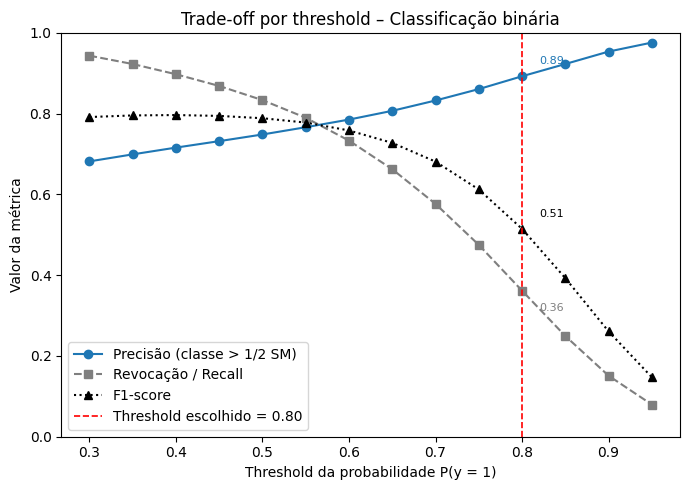

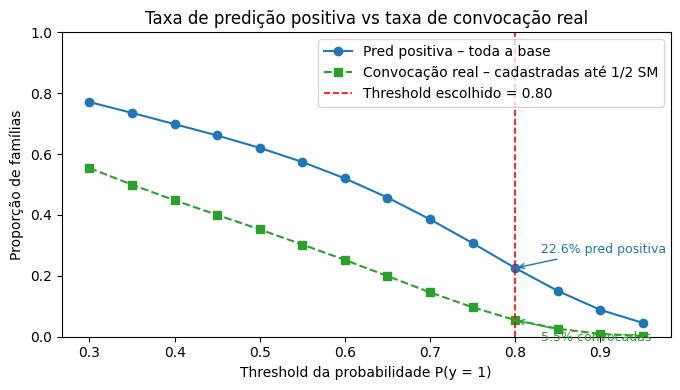

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
PRETO = "#000000"
VERM  = "red"
VERDE = "#2ca02c"
THRESHOLD_FINAL = 0.80
THRESHOLDS = np.arange(0.30, 0.96, 0.05)

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Máscara: famílias cadastradas como até 1/2 SM (classes 0 e 1)
classe_renda_test = df.loc[X_test.index, "classe_renda"]
mask_ate_meio_sm  = (classe_renda_test != 2).values

# ------------------------------------------------------------
# 2) CÁLCULO DAS MÉTRICAS POR THRESHOLD
# ------------------------------------------------------------
precisoes            = []
revocacoes           = []
f1_scores            = []
taxa_pred_positiva   = []
taxa_convocacao_real = []

for t in THRESHOLDS:
    y_pred = (proba_pos >= t).astype(int)
    precisoes.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    revocacoes.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))
    taxa_pred_positiva.append((y_pred == 1).mean())
    taxa_convocacao_real.append((y_pred[mask_ate_meio_sm] == 1).mean())

# Índice do threshold operacional
idx_thr = np.argmin(np.abs(THRESHOLDS - THRESHOLD_FINAL))

# ------------------------------------------------------------
# 3) PLOT DO TRADE-OFF (PRECISÃO, RECALL, F1)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(THRESHOLDS, precisoes,  marker="o", color=AZUL,  label="Precisão (classe > 1/2 SM)")
ax.plot(THRESHOLDS, revocacoes, marker="s", color=CINZA, linestyle="--", label="Revocação / Recall")
ax.plot(THRESHOLDS, f1_scores,  marker="^", color=PRETO, linestyle=":",  label="F1-score")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotações no threshold escolhido
ax.annotate(f"{precisoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, precisoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, precisoes[idx_thr] + 0.03),
            color=AZUL, fontsize=8)

ax.annotate(f"{revocacoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, revocacoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, revocacoes[idx_thr] - 0.05),
            color=CINZA, fontsize=8)

ax.annotate(f"{f1_scores[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, f1_scores[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, f1_scores[idx_thr] + 0.03),
            color=PRETO, fontsize=8)

ax.set_title("Trade-off por threshold – Classificação binária")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) PLOT: TAXA DE PREDIÇÃO POSITIVA vs TAXA DE CONVOCAÇÃO REAL
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(THRESHOLDS, taxa_pred_positiva,   marker="o", color=AZUL,  label="Pred positiva – toda a base")
ax.plot(THRESHOLDS, taxa_convocacao_real, marker="s", color=VERDE, linestyle="--", label="Convocação real – cadastradas até 1/2 SM")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotação: taxa de predição positiva
ax.annotate(
    f"{taxa_pred_positiva[idx_thr]:.1%} pred positiva",
    xy=(THRESHOLD_FINAL, taxa_pred_positiva[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_pred_positiva[idx_thr] + 0.05),
    arrowprops=dict(arrowstyle="->", color=AZUL),
    color=AZUL, fontsize=9
)

# Anotação: taxa de convocação real
ax.annotate(
    f"{taxa_convocacao_real[idx_thr]:.1%} convocadas",
    xy=(THRESHOLD_FINAL, taxa_convocacao_real[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_convocacao_real[idx_thr] - 0.07),
    arrowprops=dict(arrowstyle="->", color=VERDE),
    color=VERDE, fontsize=9
)

ax.set_title("Taxa de predição positiva vs taxa de convocação real")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Proporção de famílias")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


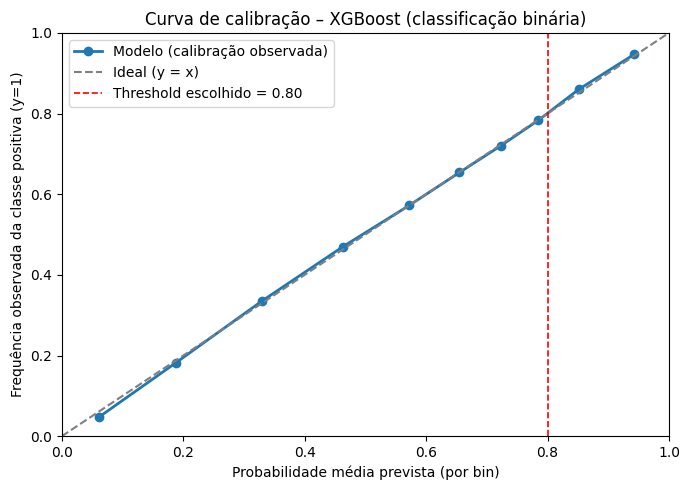

,bin,prob_media_prevista,freq_observada,dif_observada_menos_prevista
0,1,0.0617,0.0480,-0.0137
1,2,0.1881,0.1823,-0.0058
2,3,0.3291,0.3346,0.0055
3,4,0.4629,0.4698,0.0069
4,5,0.5720,0.5720,0.0000
5,6,0.6549,0.6538,-0.0011
6,7,0.7231,0.7202,-0.0029
7,8,0.7849,0.7832,-0.0017
8,9,0.8513,0.8598,0.0085
9,10,0.9431,0.9471,0.0040


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
VERM  = "red"
N_BINS = 10
THRESHOLD_FINAL = 0.80

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
frac_pos, mean_pred = calibration_curve(
    y_test,
    proba_pos,
    n_bins=N_BINS,
    strategy="quantile"
)

# ------------------------------------------------------------
# 3) PLOT DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mean_pred, frac_pos, marker="o", color=AZUL, linewidth=2,
        label="Modelo (calibração observada)")

ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.5,
        label="Ideal (y = x)")

# Marca o threshold operacional no eixo X
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

ax.set_title("Curva de calibração – XGBoost (classificação binária)")
ax.set_xlabel("Probabilidade média prevista (por bin)")
ax.set_ylabel("Frequência observada da classe positiva (y=1)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) TABELA RESUMO DOS BINS
# ------------------------------------------------------------
df_calib = pd.DataFrame({
    "bin":                          np.arange(1, len(mean_pred) + 1),
    "prob_media_prevista":          mean_pred.round(4),
    "freq_observada":               frac_pos.round(4),
    "dif_observada_menos_prevista": (frac_pos - mean_pred).round(4)
})
display(df_calib)


## Análise da importância das variáveis

In [79]:
from sklearn.inspection import permutation_importance
import pandas as pd

def plot_importancia(pipe, X, y, top_n=15, titulo="Modelo"):
    r = permutation_importance(
        pipe, X, y,
        n_repeats=5,
        random_state=42,
        scoring="f1"
    )

    feat_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

    imp = (
        pd.DataFrame({
            "feature": feat_names,
            "importance": r.importances_mean
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    fig, ax = plt.subplots()
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=AZUL)
    ax.set_title(f"Importância das variáveis (Top {top_n}) | {titulo}")
    ax.set_xlabel("Queda média no F1")
    plt.show()

    return imp



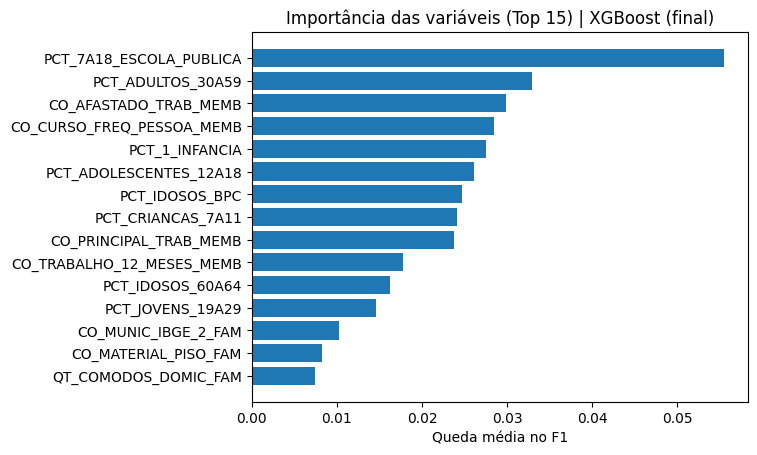

                      feature  importance
44    PCT_7A18_ESCOLA_PUBLICA    0.055512
36          PCT_ADULTOS_30A59    0.032923
28      CO_AFASTADO_TRAB_MEMB    0.029870
27  CO_CURSO_FREQ_PESSOA_MEMB    0.028487
32             PCT_1_INFANCIA    0.027544
34     PCT_ADOLESCENTES_12A18    0.026051
38             PCT_IDOSOS_BPC    0.024707
33          PCT_CRIANCAS_7A11    0.024110
29     CO_PRINCIPAL_TRAB_MEMB    0.023793
30  CO_TRABALHO_12_MESES_MEMB    0.017781
37           PCT_IDOSOS_60A64    0.016282
35           PCT_JOVENS_19A29    0.014642
1         CO_MUNIC_IBGE_2_FAM    0.010299
11       CO_MATERIAL_PISO_FAM    0.008295
8        QT_COMODOS_DOMIC_FAM    0.007452


In [80]:
imp_top = plot_importancia(
    pipe=pipeline_final,
    X=X_test,
    y=y_test,
    top_n=15,
    titulo="XGBoost (final)"
)

print(imp_top)


────────────────────────────────────────────────────────────
  PCT_7A18_ESCOLA_PUBLICA  |  tipo detectado: continua  |  importância: 0.0555
────────────────────────────────────────────────────────────


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])


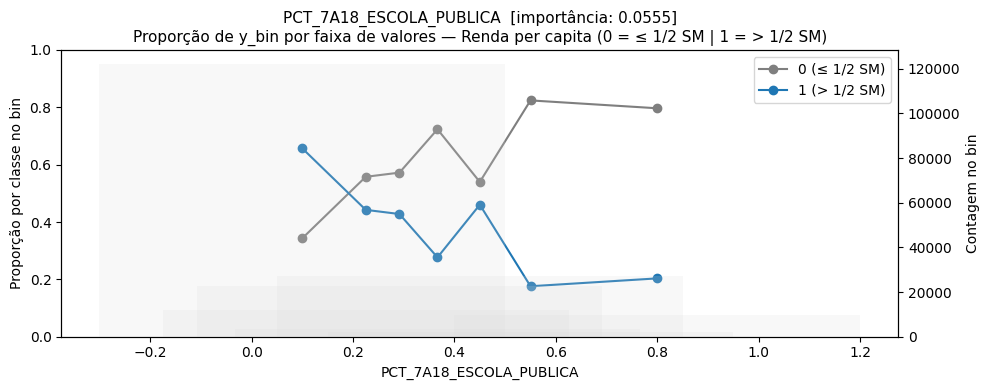

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_7A18_ESCOLA_PUBLICA,,,,
0.000000,39961,79264,119225,66.5
0.500000,14584,12604,27188,46.4
0.333333,12773,9631,22404,43.0
0.250000,6746,5355,12101,44.3
0.666667,5839,1835,7674,23.9
0.400000,2495,965,3460,27.9
0.200000,1591,990,2581,38.4
0.600000,1571,362,1933,18.7
0.750000,1662,161,1823,8.8


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])



────────────────────────────────────────────────────────────
  PCT_ADULTOS_30A59  |  tipo detectado: continua  |  importância: 0.0329
────────────────────────────────────────────────────────────


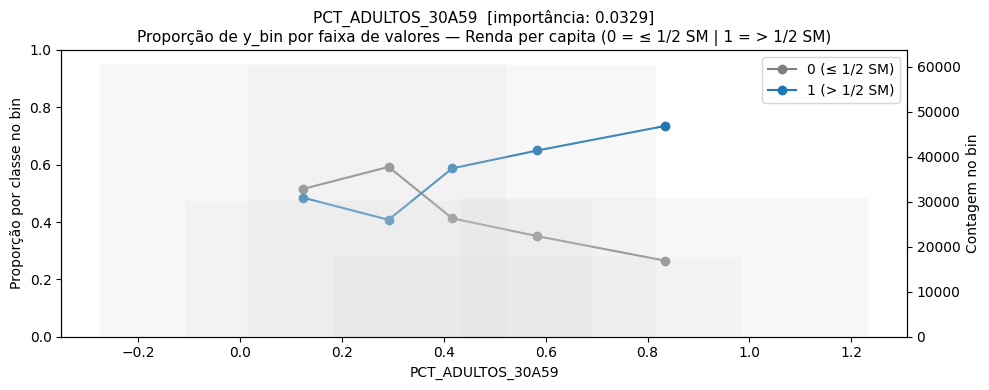

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_ADULTOS_30A59,,,,
0.500000,21480,33288,54768,60.8
0.000000,19086,25517,44603,57.2
1.000000,7977,22186,30163,73.6
0.333333,17561,12257,29818,41.1
0.666667,6107,11362,17469,65.0
0.250000,8412,3224,11636,27.7
0.400000,3474,2202,5676,38.8
0.200000,2678,565,3243,17.4
0.166667,764,95,859,11.1



────────────────────────────────────────────────────────────
  CO_AFASTADO_TRAB_MEMB  |  tipo detectado: categorica  |  importância: 0.0299
────────────────────────────────────────────────────────────


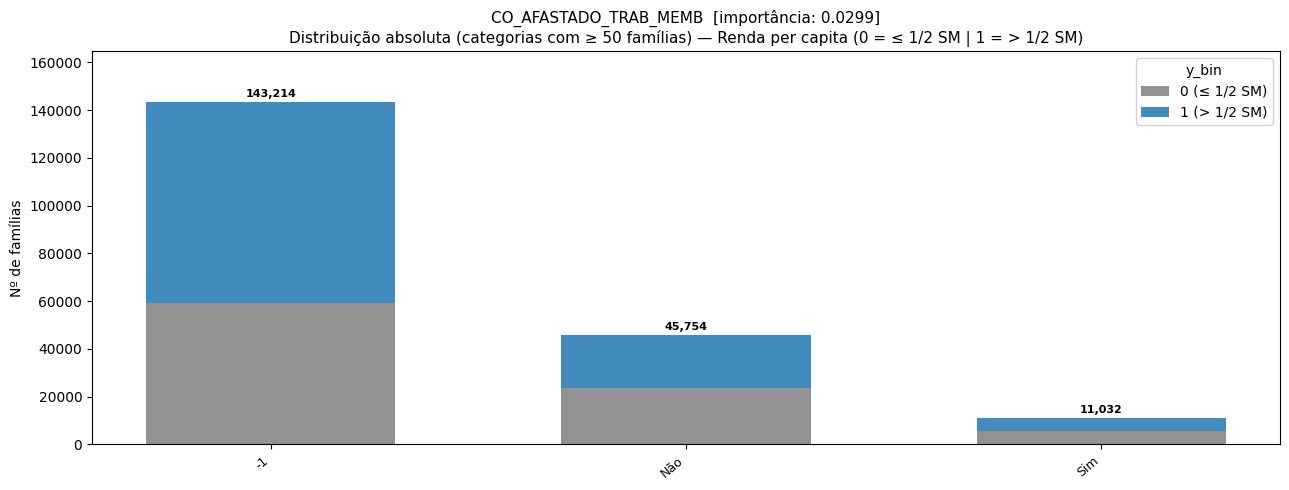

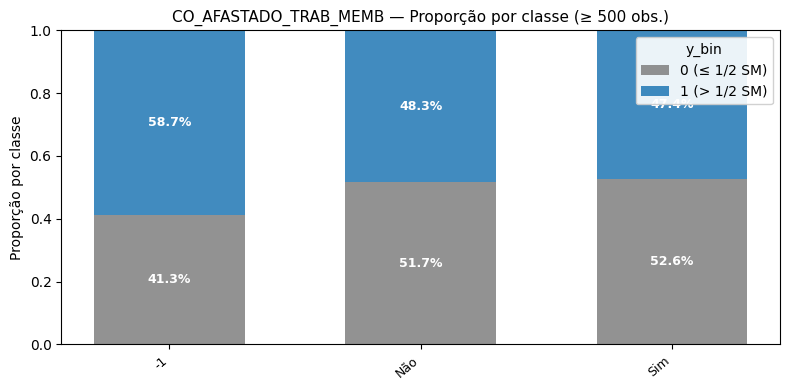

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_AFASTADO_TRAB_MEMB,,,,
-1,59098,84116,143214,58.7
2,23677,22077,45754,48.3
1,5808,5224,11032,47.4



────────────────────────────────────────────────────────────
  CO_CURSO_FREQ_PESSOA_MEMB  |  tipo detectado: categorica  |  importância: 0.0285
────────────────────────────────────────────────────────────


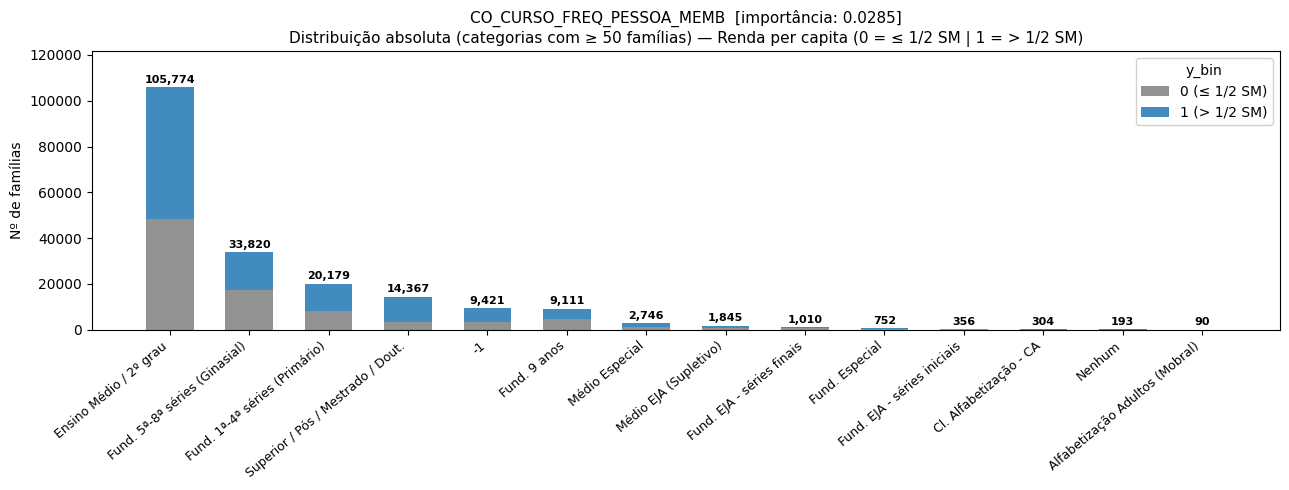

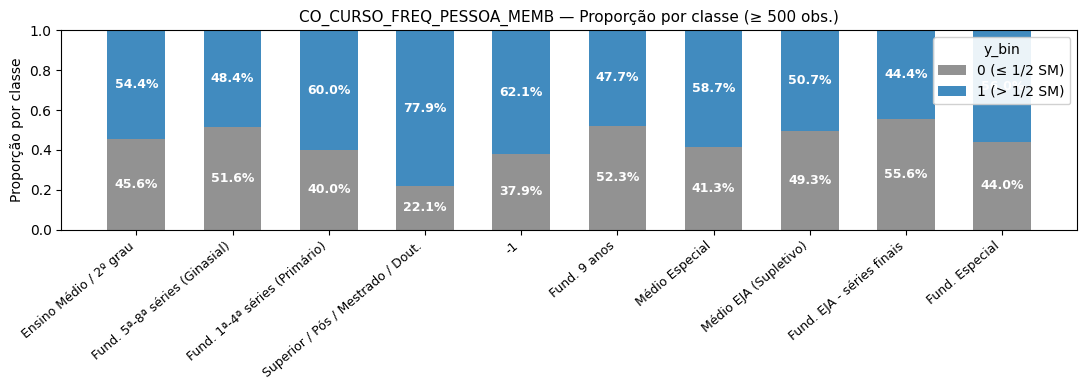

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_CURSO_FREQ_PESSOA_MEMB,,,,
8,48275,57499,105774,54.4
5,17438,16382,33820,48.4
4,8068,12111,20179,60.0
13,3173,11194,14367,77.9
-1,3570,5851,9421,62.1
6,4763,4348,9111,47.7
9,1135,1611,2746,58.7
12,910,935,1845,50.7
11,562,448,1010,44.4



────────────────────────────────────────────────────────────
  PCT_1_INFANCIA  |  tipo detectado: continua  |  importância: 0.0275
────────────────────────────────────────────────────────────


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])


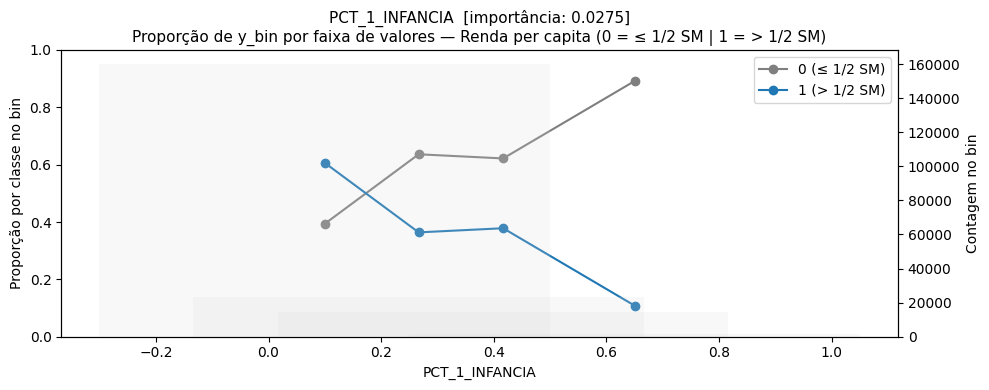

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_1_INFANCIA,,,,
0.000000,59727,96270,155997,61.7
0.333333,8897,5540,14437,38.4
0.500000,8127,5301,13428,39.5
0.250000,5839,2962,8801,33.7
0.200000,2305,769,3074,25.0
0.666667,1382,188,1570,12.0
0.400000,808,167,975,17.1
0.166667,708,143,851,16.8
0.142857,208,35,243,14.4


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])



────────────────────────────────────────────────────────────
  PCT_ADOLESCENTES_12A18  |  tipo detectado: continua  |  importância: 0.0261
────────────────────────────────────────────────────────────


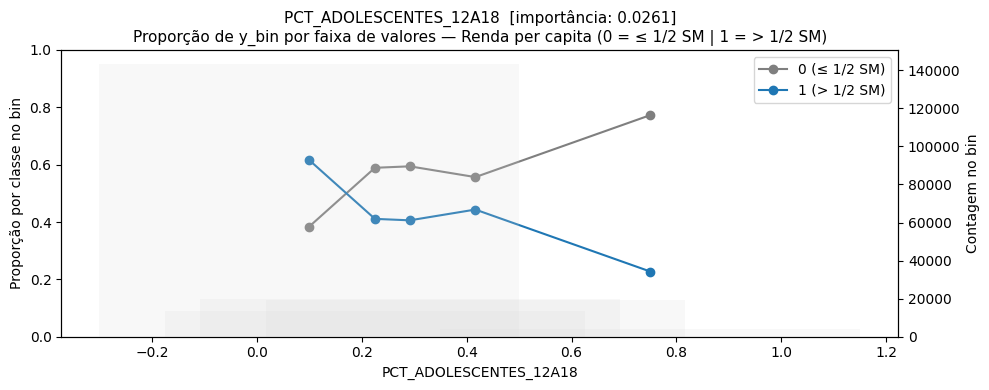

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_ADOLESCENTES_12A18,,,,
0.000000,51586,86882,138468,62.7
0.333333,11447,7957,19404,41.0
0.500000,8633,7926,16559,47.9
0.250000,7857,5496,13353,41.2
0.200000,2644,1339,3983,33.6
0.666667,2288,784,3072,25.5
0.400000,1933,625,2558,24.4
0.166667,613,172,785,21.9
0.600000,439,88,527,16.7



────────────────────────────────────────────────────────────
  PCT_IDOSOS_BPC  |  tipo detectado: categorica  |  importância: 0.0247
────────────────────────────────────────────────────────────


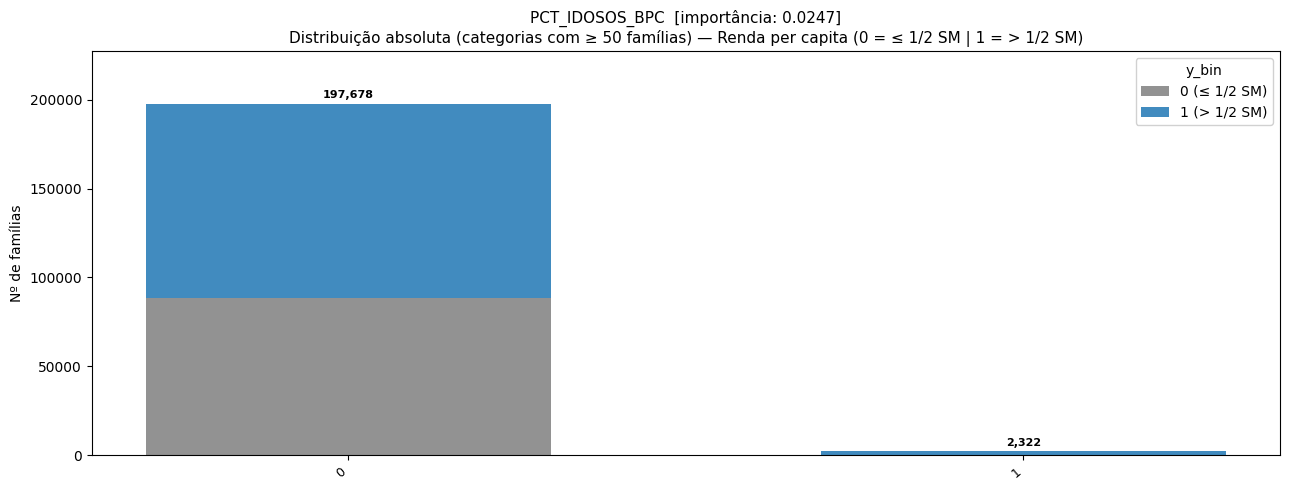

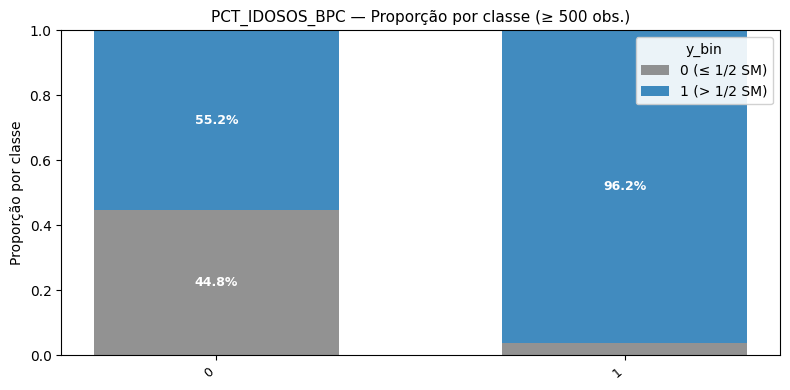

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_IDOSOS_BPC,,,,
0.000000,87332,98806,186138,53.1
0.500000,258,5496,5754,95.5
0.333333,370,2457,2827,86.9
1.000000,88,2234,2322,96.2
0.250000,249,1018,1267,80.3
0.666667,26,869,895,97.1
0.200000,143,319,462,69.0
0.166667,63,68,131,51.9
0.400000,14,99,113,87.6



────────────────────────────────────────────────────────────
  PCT_CRIANCAS_7A11  |  tipo detectado: continua  |  importância: 0.0241
────────────────────────────────────────────────────────────


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])


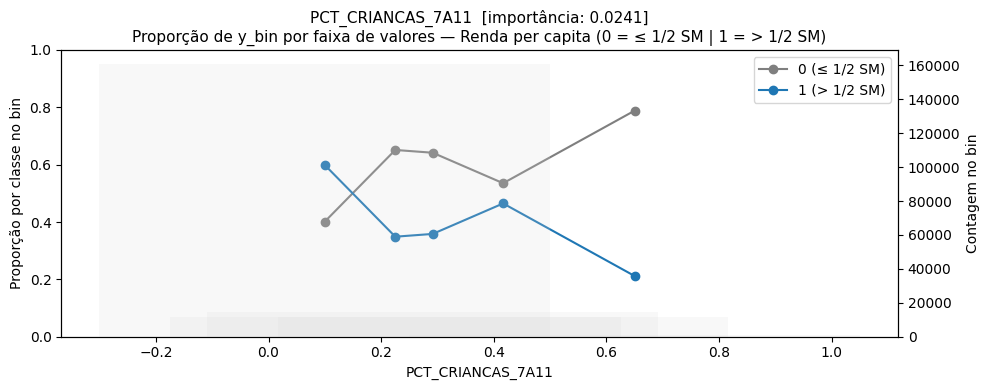

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_CRIANCAS_7A11,,,,
0.000000,60255,95186,155441,61.2
0.333333,9186,5216,14402,36.2
0.250000,7508,4035,11543,35.0
0.500000,5205,5147,10352,49.7
0.200000,3003,1105,4108,26.9
0.400000,926,218,1144,19.1
0.666667,858,252,1110,22.7
0.166667,893,184,1077,17.1
0.142857,245,32,277,11.6



────────────────────────────────────────────────────────────
  CO_PRINCIPAL_TRAB_MEMB  |  tipo detectado: categorica  |  importância: 0.0238
────────────────────────────────────────────────────────────


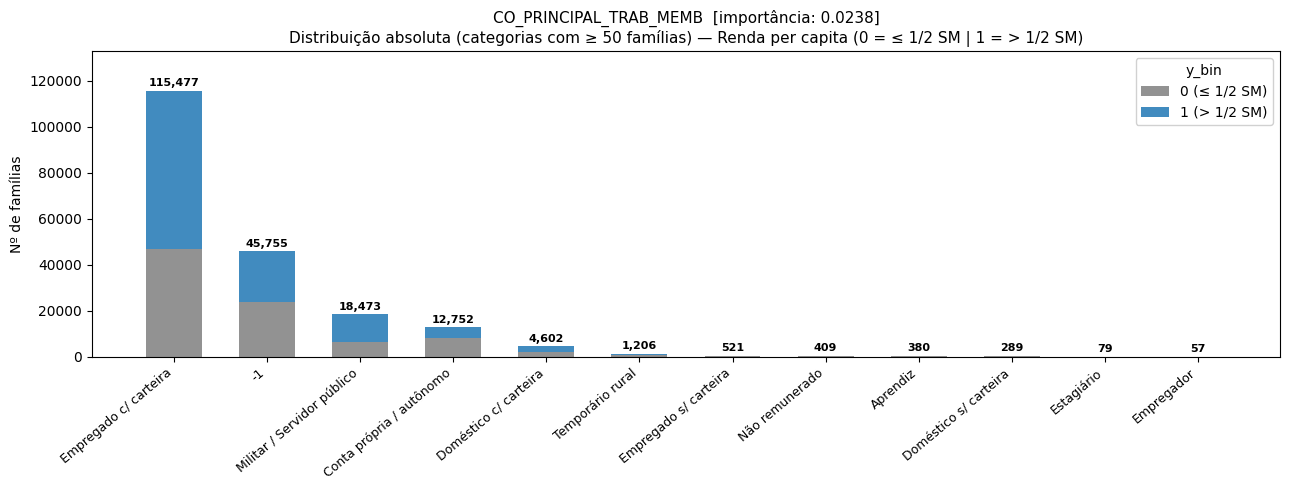

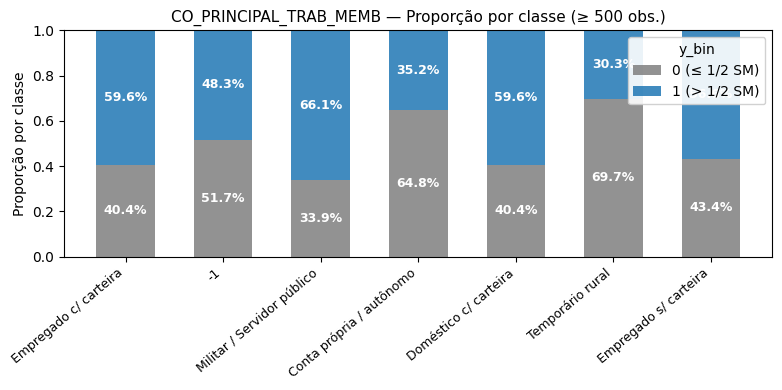

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_PRINCIPAL_TRAB_MEMB,,,,
4,46705,68772,115477,59.6
-1,23677,22078,45755,48.3
8,6263,12210,18473,66.1
1,8263,4489,12752,35.2
6,1861,2741,4602,59.6
2,840,366,1206,30.3
3,226,295,521,56.6
7,284,125,409,30.6
11,237,143,380,37.6



────────────────────────────────────────────────────────────
  CO_TRABALHO_12_MESES_MEMB  |  tipo detectado: categorica  |  importância: 0.0178
────────────────────────────────────────────────────────────


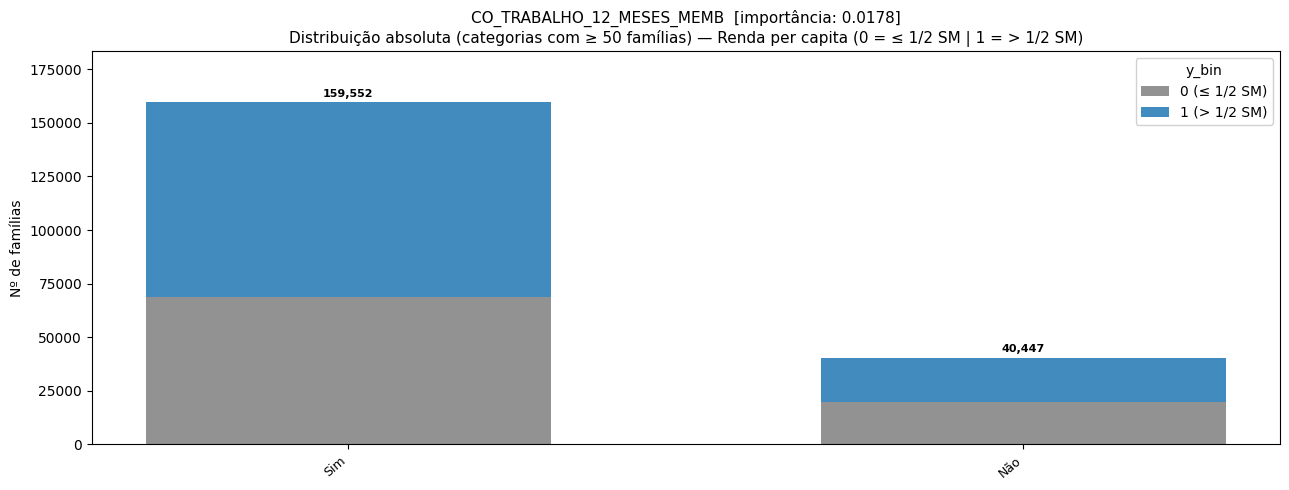

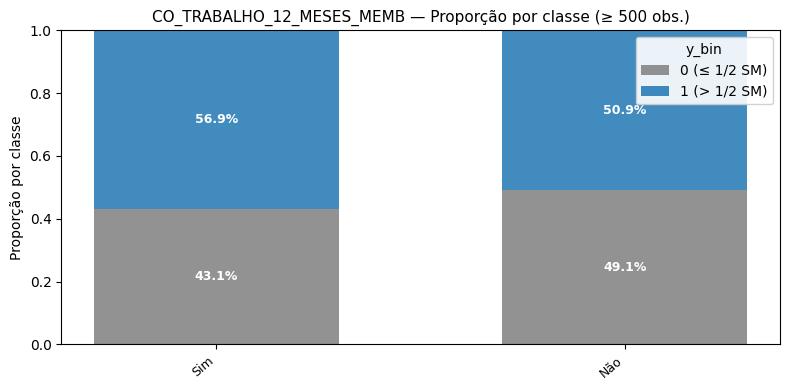

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_TRABALHO_12_MESES_MEMB,,,,
1,68718,90834,159552,56.9
2,19865,20582,40447,50.9
-1,0,1,1,100.0



────────────────────────────────────────────────────────────
  PCT_IDOSOS_60A64  |  tipo detectado: categorica  |  importância: 0.0163
────────────────────────────────────────────────────────────


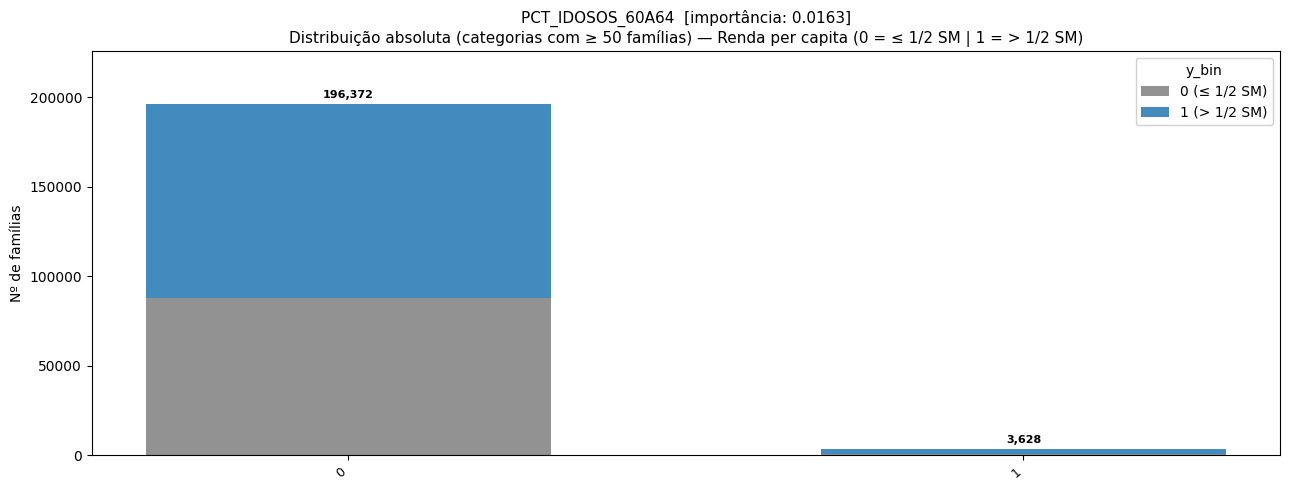

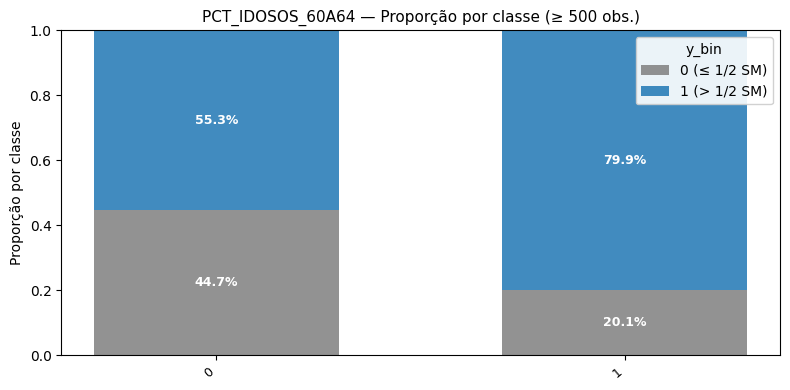

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_IDOSOS_60A64,,,,
0.000000,85200,99363,184563,53.8
0.500000,988,4916,5904,83.3
1.000000,731,2897,3628,79.9
0.333333,761,2492,3253,76.6
0.250000,476,974,1450,67.2
0.666667,94,402,496,81.0
0.200000,182,261,443,58.9
0.166667,90,46,136,33.8
0.400000,20,45,65,69.2



────────────────────────────────────────────────────────────
  PCT_JOVENS_19A29  |  tipo detectado: continua  |  importância: 0.0146
────────────────────────────────────────────────────────────


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])


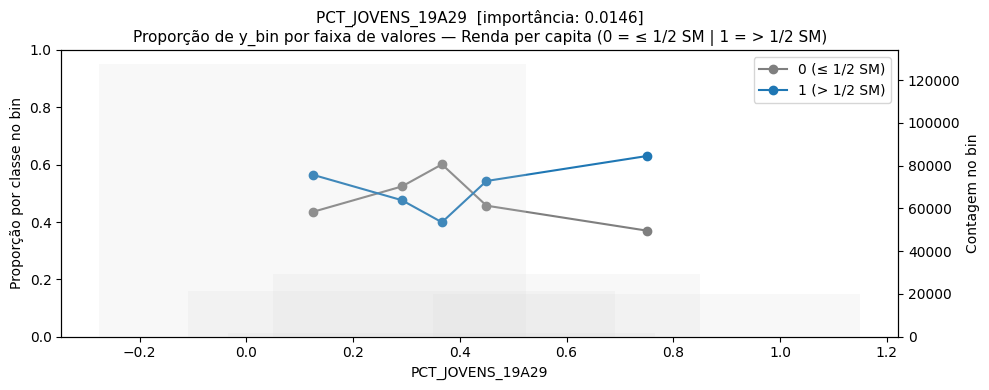

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_JOVENS_19A29,,,,
0.000000,45973,66308,112281,59.1
0.500000,13320,15888,29208,54.4
0.333333,11148,10207,21355,47.8
1.000000,4139,9286,13425,69.2
0.250000,6306,4604,10910,42.2
0.666667,2719,2725,5444,50.1
0.200000,2363,1036,3399,30.5
0.400000,973,657,1630,40.3
0.166667,657,164,821,20.0



────────────────────────────────────────────────────────────
  CO_MUNIC_IBGE_2_FAM  |  tipo detectado: categorica  |  importância: 0.0103
────────────────────────────────────────────────────────────


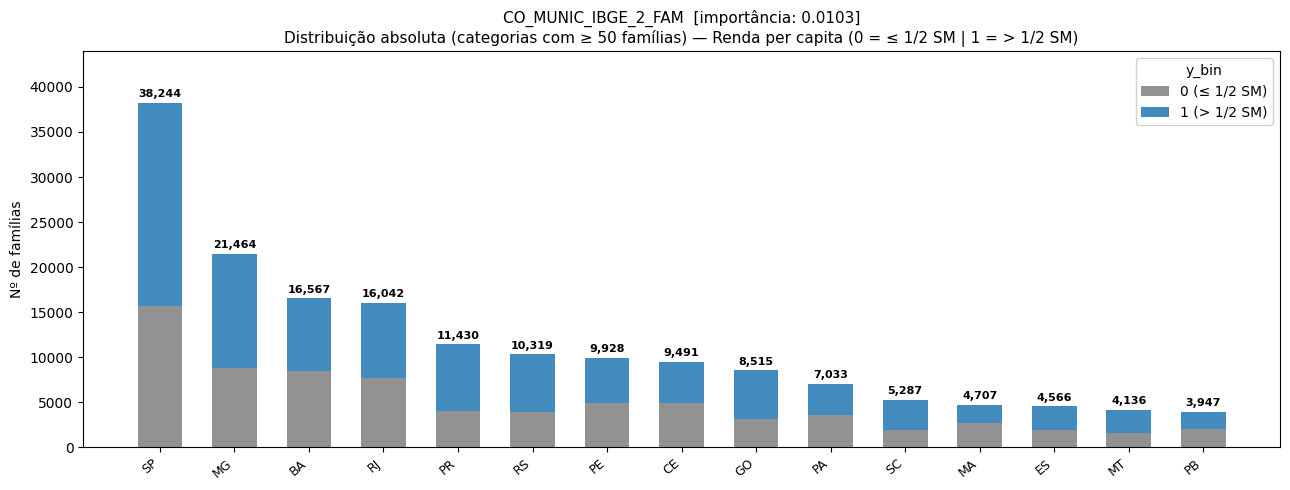

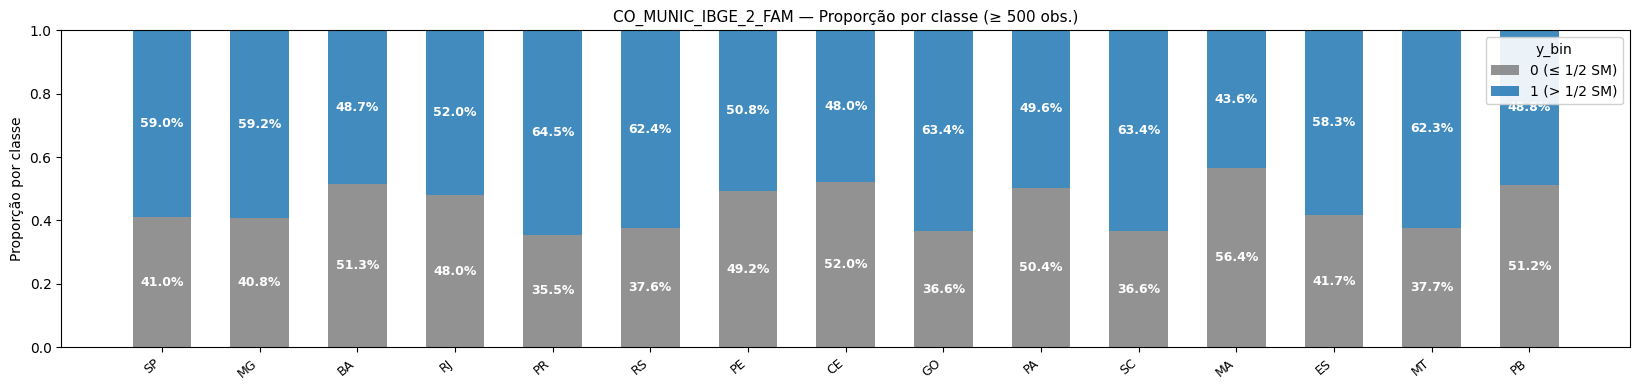

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_MUNIC_IBGE_2_FAM,,,,
35,15672,22572,38244,59.0
31,8750,12714,21464,59.2
29,8506,8061,16567,48.7
33,7701,8341,16042,52.0
41,4054,7376,11430,64.5
43,3875,6444,10319,62.4
26,4885,5043,9928,50.8
23,4937,4554,9491,48.0
52,3116,5399,8515,63.4



────────────────────────────────────────────────────────────
  CO_MATERIAL_PISO_FAM  |  tipo detectado: categorica  |  importância: 0.0083
────────────────────────────────────────────────────────────


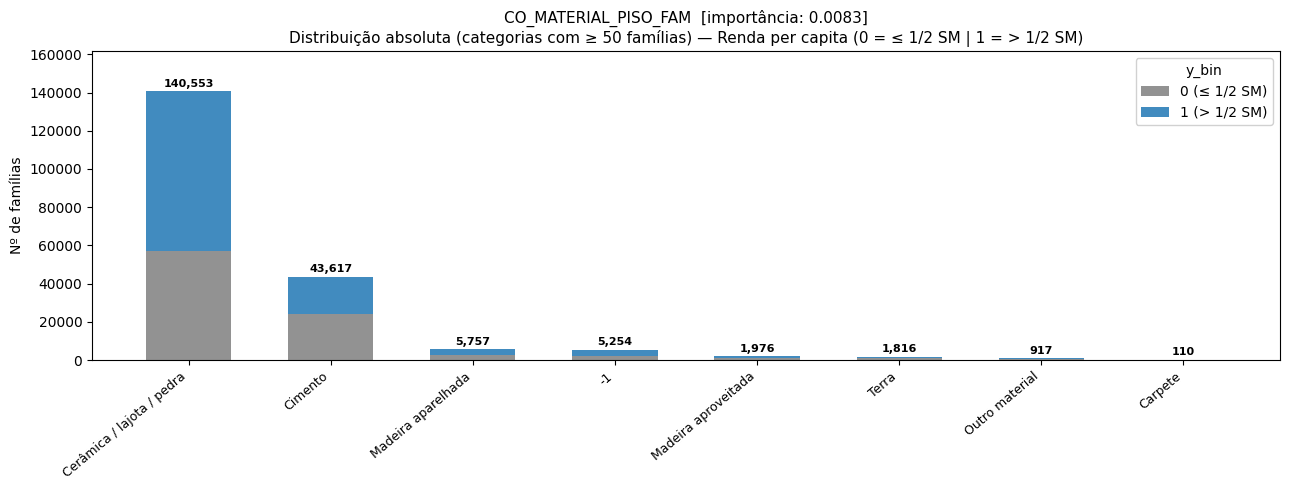

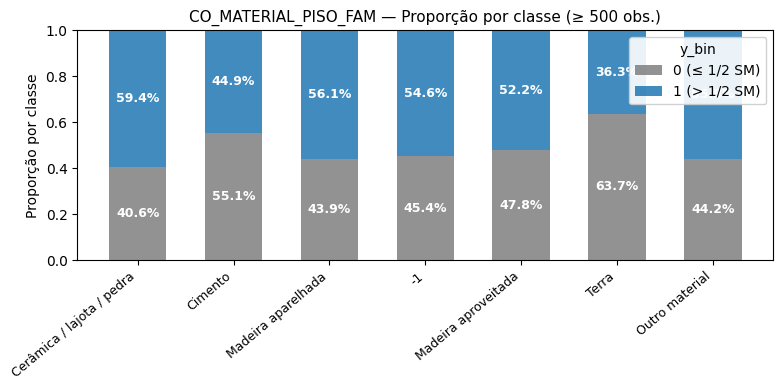

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_MATERIAL_PISO_FAM,,,,
5,57068,83485,140553,59.4
2,24053,19564,43617,44.9
4,2529,3228,5757,56.1
-1,2385,2869,5254,54.6
3,945,1031,1976,52.2
1,1157,659,1816,36.3
7,405,512,917,55.8
6,41,69,110,62.7



────────────────────────────────────────────────────────────
  QT_COMODOS_DOMIC_FAM  |  tipo detectado: continua  |  importância: 0.0075
────────────────────────────────────────────────────────────


C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1392442876.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab  = (df_plot.groupby(["bin", TARGET])


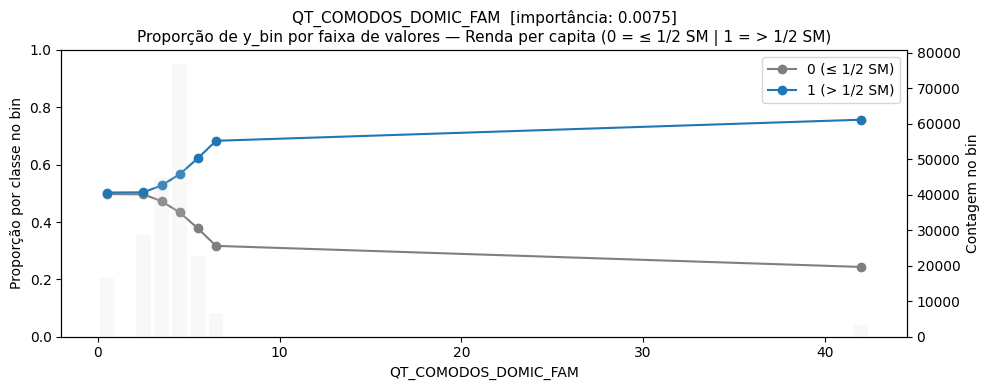

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
QT_COMODOS_DOMIC_FAM,,,,
5,33315,43570,76885,56.7
4,21131,23578,44709,52.7
3,14257,14461,28718,50.4
6,8634,14222,22856,62.2
2,5070,4795,9865,48.6
7,2152,4641,6793,68.3
-1,2385,2869,5254,54.6
8,605,1687,2292,73.6
1,802,680,1482,45.9


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ─────────────────────────────────────────────
# CONFIG GERAL
# ─────────────────────────────────────────────
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"
AZUL_ESCURO = "#0b2d5b"

TARGET      = "y_bin"
CLASSES     = [0, 1]
LEGENDAS    = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
CORES       = {0: CINZA, 1: AZUL}

N_BINS          = 20
TOP_CAT         = 15
MIN_COUNT       = 50
MIN_VOL_PROP    = 500   # volume mínimo para aparecer no gráfico de proporção categórico

TARGET_LABEL = "Renda per capita (0 = ≤ 1/2 SM | 1 = > 1/2 SM)"

# ─────────────────────────────────────────────
# VARIÁVEIS DO imp_top (nome → importância)
# ─────────────────────────────────────────────
variaveis_imp = {
    "PCT_7A18_ESCOLA_PUBLICA"   : 0.055512,
    "PCT_ADULTOS_30A59"         : 0.032923,
    "CO_AFASTADO_TRAB_MEMB"     : 0.029870,
    "CO_CURSO_FREQ_PESSOA_MEMB" : 0.028487,
    "PCT_1_INFANCIA"            : 0.027544,
    "PCT_ADOLESCENTES_12A18"    : 0.026051,
    "PCT_IDOSOS_BPC"            : 0.024707,
    "PCT_CRIANCAS_7A11"         : 0.024110,
    "CO_PRINCIPAL_TRAB_MEMB"    : 0.023793,
    "CO_TRABALHO_12_MESES_MEMB" : 0.017781,
    "PCT_IDOSOS_60A64"          : 0.016282,
    "PCT_JOVENS_19A29"          : 0.014642,
    "CO_MUNIC_IBGE_2_FAM"       : 0.010299,
    "CO_MATERIAL_PISO_FAM"      : 0.008295,
    "QT_COMODOS_DOMIC_FAM"      : 0.007452,
}

# ─────────────────────────────────────────────
# MAPEAMENTOS CATEGÓRICOS CONHECIDOS
# ─────────────────────────────────────────────
MAPAS = {
    "CO_CURSO_FREQ_PESSOA_MEMB": {
        1:  "Creche",
        2:  "Pré-escola (exceto CA)",
        3:  "Cl. Alfabetização - CA",
        4:  "Fund. 1ª-4ª séries (Primário)",
        5:  "Fund. 5ª-8ª séries (Ginasial)",
        6:  "Fund. 9 anos",
        7:  "Fund. Especial",
        8:  "Ensino Médio / 2º grau",
        9:  "Médio Especial",
        10: "Fund. EJA - séries iniciais",
        11: "Fund. EJA - séries finais",
        12: "Médio EJA (Supletivo)",
        13: "Superior / Pós / Mestrado / Dout.",
        14: "Alfabetização Adultos (Mobral)",
        15: "Nenhum",
    },
    "CO_PRINCIPAL_TRAB_MEMB": {
        1:  "Conta própria / autônomo",
        2:  "Temporário rural",
        3:  "Empregado s/ carteira",
        4:  "Empregado c/ carteira",
        5:  "Doméstico s/ carteira",
        6:  "Doméstico c/ carteira",
        7:  "Não remunerado",
        8:  "Militar / Servidor público",
        9:  "Empregador",
        10: "Estagiário",
        11: "Aprendiz",
    },
    "CO_MATERIAL_PISO_FAM": {
        1: "Terra",
        2: "Cimento",
        3: "Madeira aproveitada",
        4: "Madeira aparelhada",
        5: "Cerâmica / lajota / pedra",
        6: "Carpete",
        7: "Outro material",
    },
    "CO_AFASTADO_TRAB_MEMB": {
        1: "Sim",
        2: "Não",
    },
    "CO_TRABALHO_12_MESES_MEMB": {
        1: "Sim",
        2: "Não",
    },
   
    "CO_MUNIC_IBGE_2_FAM": {
        11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA",
        16: "AP", 17: "TO", 21: "MA", 22: "PI", 23: "CE",
        24: "RN", 25: "PB", 26: "PE", 27: "AL", 28: "SE",
        29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
        41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT",
        52: "GO", 53: "DF",
    },
}

# ─────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ─────────────────────────────────────────────
def detectar_tipo(series, col):
    """Retorna 'binaria', 'continua' ou 'categorica'."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    n_unique = s.nunique()

    if n_unique == 2:
        return "binaria"
    if col in MAPAS or n_unique <= 20:
        return "categorica"
    return "continua"


def aplicar_mapa(series, col):
    """Aplica mapeamento textual se existir, senão usa o valor original como string."""
    mapa = MAPAS.get(col, {})
    def rotular(v):
        if pd.isna(v):
            return "Sem informação"
        k = int(v)
        return mapa.get(k, str(k))
    return series.apply(rotular)


# ─────────────────────────────────────────────
# GRÁFICOS POR TIPO
# ─────────────────────────────────────────────
def plot_continua(df_plot, col, importancia):
    q = min(N_BINS, df_plot[col].nunique())
    df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

    tab  = (df_plot.groupby(["bin", TARGET])
                   .size().unstack(fill_value=0)
                   .reindex(columns=CLASSES, fill_value=0))
    prop    = tab.div(tab.sum(axis=1), axis=0)
    centers = np.array([(b.left + b.right) / 2 for b in prop.index])
    counts  = tab.sum(axis=1).to_numpy()

    fig, ax1 = plt.subplots(figsize=(10, 4))
    for k in CLASSES:
        ax1.plot(centers, prop[k].to_numpy(),
                 marker="o", linewidth=1.5,
                 color=CORES[k], label=LEGENDAS[k])
    ax1.set_ylim(0, 1)
    ax1.set_xlabel(col)
    ax1.set_ylabel("Proporção por classe no bin")
    ax1.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Proporção de {TARGET} por faixa de valores — {TARGET_LABEL}",
        fontsize=11
    )
    ax1.legend(loc="upper right")
    ax1.grid(False)

    ax2 = ax1.twinx()
    ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
    ax2.set_ylabel("Contagem no bin")
    plt.tight_layout()
    plt.show()


def plot_categorica(df_plot, col, importancia):
    df_plot["rotulo"] = aplicar_mapa(
        pd.to_numeric(df_plot[col], errors="coerce"), col
    )

    top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
    df_plot = df_plot[df_plot["rotulo"].isin(top)].copy()

    tab    = (df_plot.groupby(["rotulo", TARGET])
                     .size().unstack(fill_value=0)
                     .reindex(columns=CLASSES, fill_value=0))
    prop   = tab.div(tab.sum(axis=1), axis=0)
    counts = tab.sum(axis=1)

    # ── Filtro de volume mínimo para o gráfico de barras ─────
    mask_min = counts >= MIN_COUNT   # MIN_COUNT = 50 já definido no config
    tab_vol    = tab.loc[mask_min]
    counts_vol = counts.loc[mask_min]
    prop_vol   = prop.loc[mask_min]

    # Ordenação por volume decrescente
    ordem = counts_vol.sort_values(ascending=False).index
    prop_vol   = prop_vol.loc[ordem]
    tab_vol    = tab_vol.loc[ordem]
    counts_vol = counts_vol.loc[ordem]
    x_all      = np.arange(len(prop_vol.index))

    # — Plot 1: volume absoluto (apenas categorias com >= MIN_COUNT) —
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x_all, tab_vol[0].to_numpy(), width=0.6,
           color=CINZA, label=LEGENDAS[0], alpha=0.85)
    ax.bar(x_all, tab_vol[1].to_numpy(), width=0.6,
           color=AZUL,  label=LEGENDAS[1], alpha=0.85,
           bottom=tab_vol[0].to_numpy())
    for i, total in enumerate(counts_vol):
        ax.text(i, total + counts_vol.max() * 0.01,
                f"{total:,.0f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
    ax.set_ylim(0, counts_vol.max() * 1.15)
    ax.set_xticks(x_all)
    ax.set_xticklabels(prop_vol.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Nº de famílias")
    ax.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Distribuição absoluta (categorias com ≥ {MIN_COUNT} famílias) — {TARGET_LABEL}",
        fontsize=11
    )
    ax.legend(title=TARGET, loc="upper right",
              bbox_to_anchor=(1, 1), framealpha=0.9)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    # — Plot 2: proporção (apenas categorias com >= MIN_VOL_PROP) —
    mask   = counts >= MIN_VOL_PROP
    prop_f = prop.loc[mask]
    if prop_f.empty:
        print(f"  ⚠ Nenhuma categoria de '{col}' com ≥ {MIN_VOL_PROP} obs.")
        return

    # Reordena por volume para manter consistência com plot 1
    ordem_f = counts.loc[mask].sort_values(ascending=False).index
    prop_f  = prop_f.loc[ordem_f]
    x_f     = np.arange(len(prop_f.index))
    bottom  = np.zeros(len(prop_f.index))

    fig, ax = plt.subplots(figsize=(max(8, len(prop_f) * 1.1), 4))
    for k in CLASSES:
        vals = prop_f[k].to_numpy()
        ax.bar(x_f, vals, bottom=bottom, width=0.6,
               label=LEGENDAS[k], color=CORES[k], alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.1%}",
                        ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottom += vals
    ax.set_xticks(x_f)
    ax.set_xticklabels(prop_f.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proporção por classe")
    ax.set_title(
        f"{col} — Proporção por classe (≥ {MIN_VOL_PROP:,} obs.)",
        fontsize=11
    )
    ax.legend(title=TARGET, loc="upper right",
              bbox_to_anchor=(1, 1), framealpha=0.9)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_binaria(df_plot, col, importancia):
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
    df_plot = df_plot.dropna(subset=[col])
    df_plot["rotulo"] = df_plot[col].astype(int).astype(str)

    tab    = (df_plot.groupby(["rotulo", TARGET])
                     .size().unstack(fill_value=0)
                     .reindex(columns=CLASSES, fill_value=0))
    prop   = tab.div(tab.sum(axis=1), axis=0)
    counts = tab.sum(axis=1)
    x_all  = np.arange(len(prop.index))

    fig, ax = plt.subplots(figsize=(5, 4))
    bottom = np.zeros(len(prop.index))
    for k in CLASSES:
        vals = prop[k].to_numpy()
        ax.bar(x_all, vals, bottom=bottom, width=0.5,
               label=LEGENDAS[k], color=CORES[k], alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.1%}",
                        ha="center", va="center",
                        fontsize=10, color="white", fontweight="bold")
        bottom += vals
    for i, total in enumerate(counts):
        ax.text(i, 1.02, f"n={total:,.0f}", ha="center",
                fontsize=8, color="gray")
    ax.set_xticks(x_all)
    ax.set_xticklabels(prop.index, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Proporção por classe")
    ax.set_xlabel(col)
    ax.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Proporção de {TARGET} — {TARGET_LABEL}",
        fontsize=11
    )
    ax.legend(title=TARGET)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# LOOP PRINCIPAL — roda para todas as variáveis
# ─────────────────────────────────────────────
for col, imp in variaveis_imp.items():
    if col not in X_test.columns:
        print(f"⚠ Coluna '{col}' não encontrada em X_test — pulando.")
        continue

    df_plot = X_test[[col]].copy()
    df_plot[TARGET] = y_test.values

    tipo = detectar_tipo(df_plot[col], col)
    print(f"\n{'─'*60}")
    print(f"  {col}  |  tipo detectado: {tipo}  |  importância: {imp:.4f}")
    print(f"{'─'*60}")

    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
    df_plot = df_plot.dropna(subset=[col, TARGET])

    if tipo == "continua":
        plot_continua(df_plot.copy(), col, imp)
    elif tipo == "categorica":
        plot_categorica(df_plot.copy(), col, imp)
    else:
        plot_binaria(df_plot.copy(), col, imp)

    # Tabela resumo por variável
    resumo = (df_plot.groupby([col, TARGET]).size()
              .unstack(fill_value=0)
              .reindex(columns=CLASSES, fill_value=0))
    resumo.columns = [LEGENDAS[c] for c in CLASSES]
    resumo["Total"]    = resumo.sum(axis=1)
    resumo["% Cl. 1"]  = (resumo[LEGENDAS[1]] / resumo["Total"] * 100).round(1)
    resumo = resumo.sort_values("Total", ascending=False).head(TOP_CAT)
    with pd.option_context("display.max_colwidth", 60):
        display(resumo)

C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\210754078.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


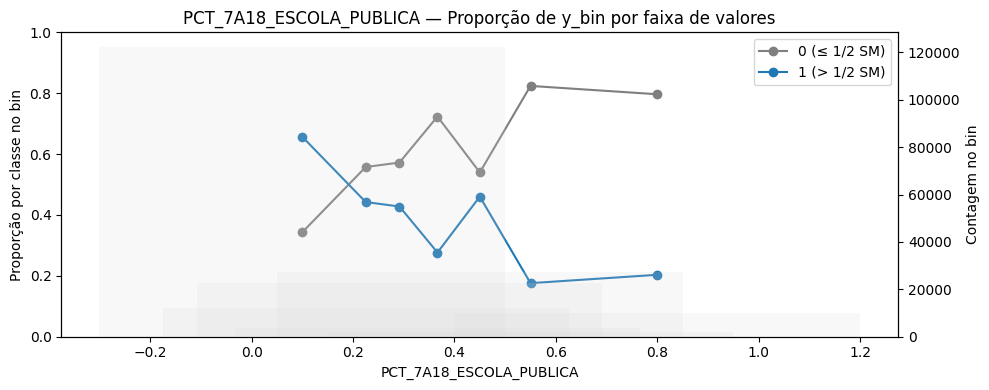

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_7A18_ESCOLA_PUBLICA"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()



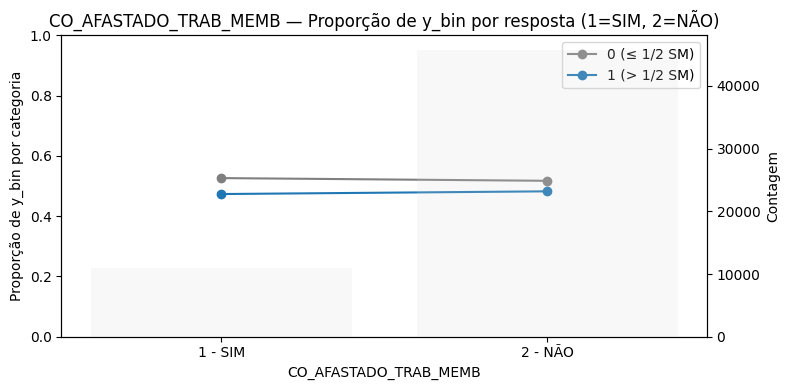

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "CO_AFASTADO_TRAB_MEMB"   # 1=SIM, 2=NÃO
target = "y_bin"                # 0/1

# mapa de rótulos (ajuste se houver outros códigos)
mapa_col = {1: "1 - SIM", 2: "2 - NÃO"}
mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# manter apenas 1 e 2 (opcional, mas recomendado)
df_plot = df_plot[df_plot[col].isin([1, 2])].copy()

# aplicar rótulos
df_plot["categoria"] = df_plot[col].map(mapa_col).fillna(df_plot[col].astype(int).astype(str))

# -----------------------------
# TABELA: contagem e proporção por categoria
# -----------------------------
tab = (
    df_plot.groupby(["categoria", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=[0, 1], fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1)

# ordenar categorias (SIM primeiro, depois NÃO)
ordem = ["1 - SIM", "2 - NÃO"]
prop = prop.reindex([c for c in ordem if c in prop.index] + [c for c in prop.index if c not in ordem])
counts = counts.reindex(prop.index)

# -----------------------------
# PLOT
# -----------------------------
x = np.arange(len(prop.index))

fig, ax1 = plt.subplots(figsize=(8, 4))

# proporções (linhas ou barras). Aqui mantive linhas para "mesma lógica" do seu gráfico.
ax1.plot(x, prop[0].to_numpy(), marker="o", linewidth=1.5, color=CINZA, label=mapa_y[0])
ax1.plot(x, prop[1].to_numpy(), marker="o", linewidth=1.5, color=AZUL,  label=mapa_y[1])

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(prop.index)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção de y_bin por categoria")
ax1.set_title(f"{col} — Proporção de y_bin por resposta (1=SIM, 2=NÃO)")
ax1.legend(loc="upper right")
ax1.grid(False)

# contagem no eixo secundário
ax2 = ax1.twinx()
ax2.bar(x, counts.to_numpy(), alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem")

plt.tight_layout()
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\1245142794.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


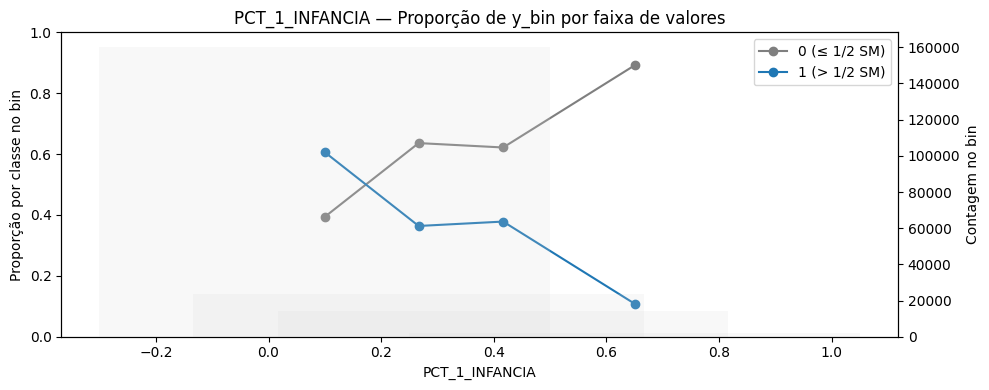

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_1_INFANCIA"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_58816\658949938.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


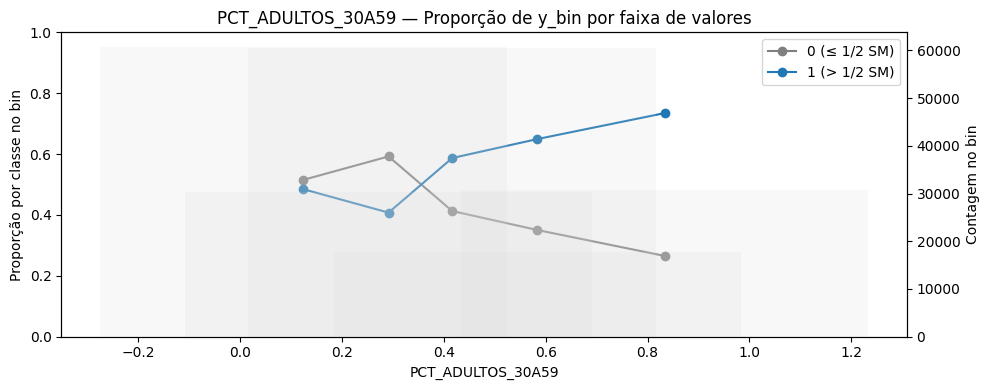

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_ADULTOS_30A59"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


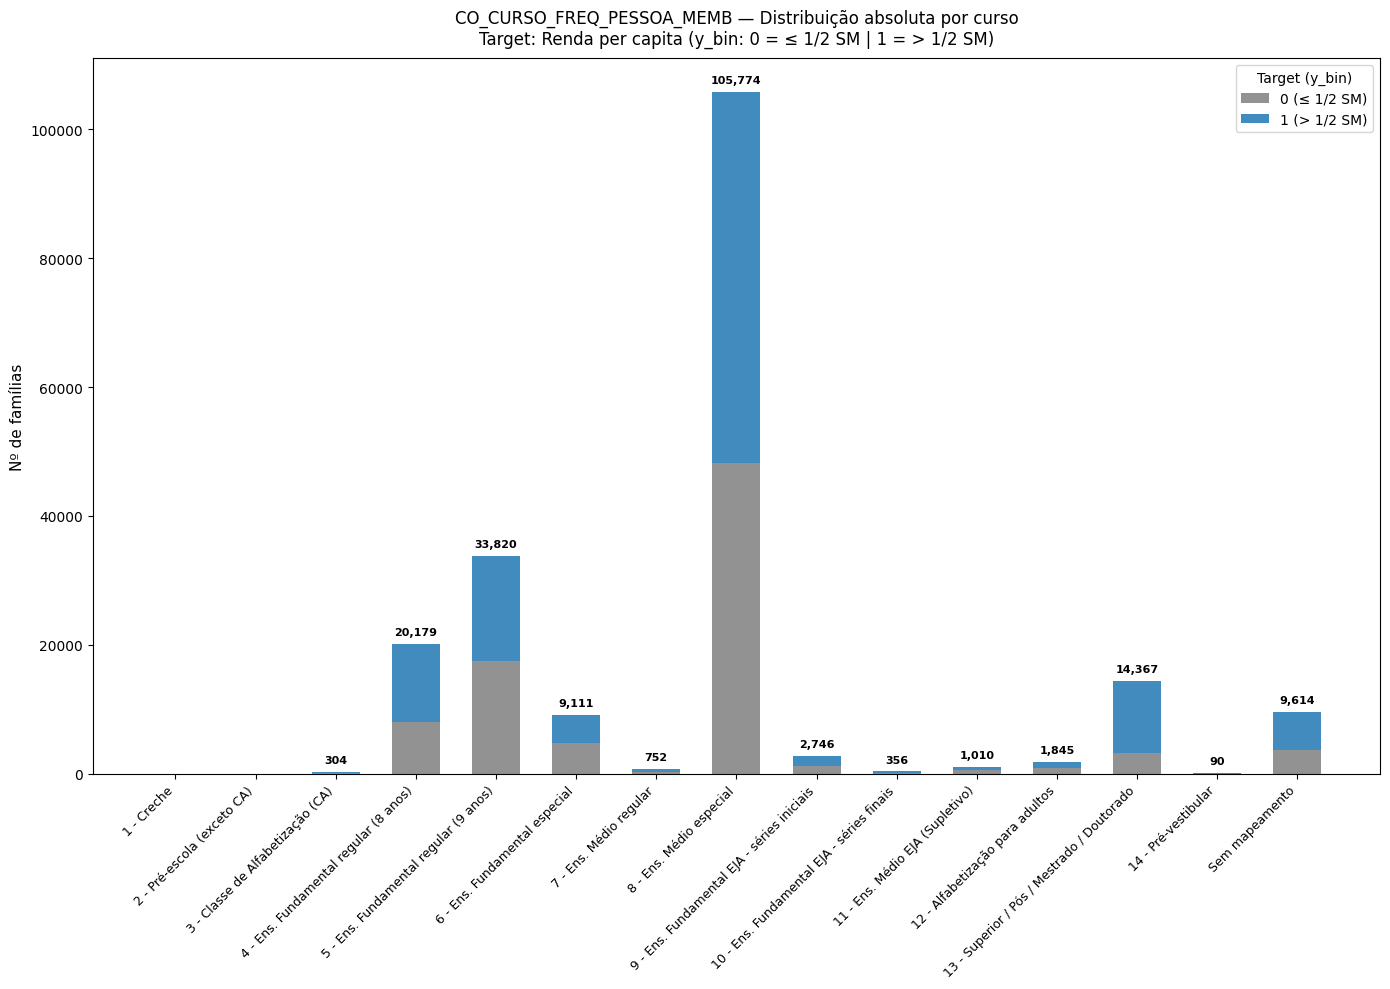

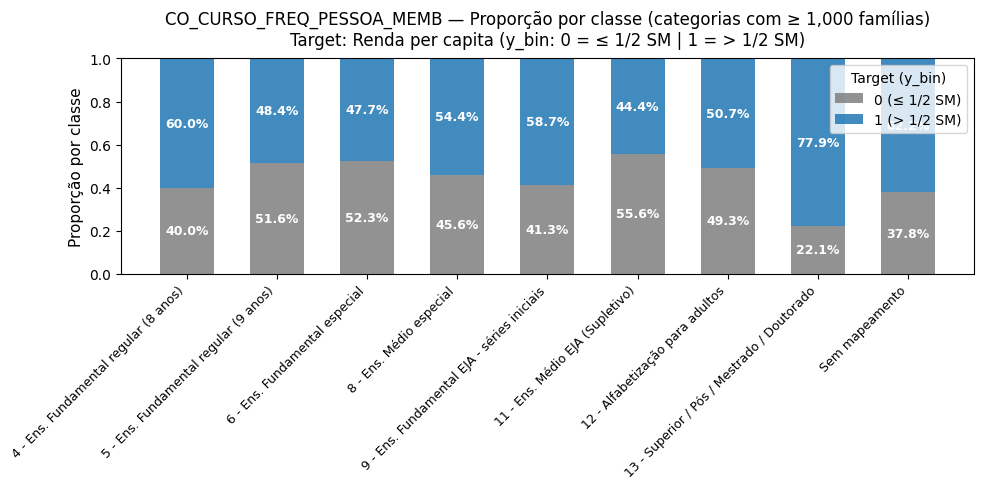


  CO_CURSO_FREQ_PESSOA_MEMB — Distribuição por curso
  (gráfico 2 filtra categorias com ≥ 1,000 famílias)


,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
rotulo,,,,
8 - Ens. Médio especial,48275,57499,105774,54.4
5 - Ens. Fundamental regular (9 anos),17438,16382,33820,48.4
4 - Ens. Fundamental regular (8 anos),8068,12111,20179,60.0
13 - Superior / Pós / Mestrado / Doutorado,3173,11194,14367,77.9
Sem mapeamento,3635,5979,9614,62.2
6 - Ens. Fundamental especial,4763,4348,9111,47.7
9 - Ens. Fundamental EJA - séries iniciais,1135,1611,2746,58.7
12 - Alfabetização para adultos,910,935,1845,50.7
11 - Ens. Médio EJA (Supletivo),562,448,1010,44.4


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
col       = "CO_CURSO_FREQ_PESSOA_MEMB"
target    = "y_bin"
CLASSES   = [0, 1]
TOP_CAT   = 20
MIN_COUNT = 50
MIN_VOL_GRAFICO2 = 1000   # volume mínimo para aparecer no gráfico de proporção
AZUL      = "#1f77b4"
CINZA     = "#7f7f7f"
AZUL_ESCURO = "#0b2d5b"
TARGET_LABEL = "Renda per capita (y_bin: 0 = ≤ 1/2 SM | 1 = > 1/2 SM)"

# -----------------------------
# MAPEAMENTO
# -----------------------------
map_curso = {
    1:  "1 - Creche",
    2:  "2 - Pré-escola (exceto CA)",
    3:  "3 - Classe de Alfabetização (CA)",
    4:  "4 - Ens. Fundamental regular (8 anos)",
    5:  "5 - Ens. Fundamental regular (9 anos)",
    6:  "6 - Ens. Fundamental especial",
    7:  "7 - Ens. Médio regular",
    8:  "8 - Ens. Médio especial",
    9:  "9 - Ens. Fundamental EJA - séries iniciais",
    10: "10 - Ens. Fundamental EJA - séries finais",
    11: "11 - Ens. Médio EJA (Supletivo)",
    12: "12 - Alfabetização para adultos",
    13: "13 - Superior / Pós / Mestrado / Doutorado",
    14: "14 - Pré-vestibular",
}
CODIGOS_VALIDOS = set(map_curso.keys())

# -----------------------------
# DADOS
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot["categoria_cod"] = df_plot[col]

df_plot.loc[
    ~df_plot["categoria_cod"].isin(CODIGOS_VALIDOS) & df_plot["categoria_cod"].notna(),
    "categoria_cod"
] = -2

def rotular(c):
    if pd.isna(c):
        return "Sem informação"
    c = int(c)
    if c == -2:
        return "Sem mapeamento"
    return map_curso.get(c, "Sem mapeamento")

df_plot["rotulo"] = df_plot["categoria_cod"].apply(rotular)

top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot["rotulo"].isin(top)].copy()

# -----------------------------
# TABELA BASE
# -----------------------------
tab = (
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1)

def ordem_rotulo(r):
    if r.startswith("Sem mapeamento"): return 950
    if r == "Sem informação":          return 999
    try:    return int(str(r).split(" - ", 1)[0])
    except: return 998

# Ordenação por código para ambos os gráficos
ordem = sorted(prop.index, key=ordem_rotulo)
prop   = prop.loc[ordem]
tab    = tab.loc[ordem]
counts = counts.loc[ordem]

cores    = {0: CINZA, 1: AZUL}
legendas = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
x_all    = np.arange(len(prop.index))

# ============================================================
# PLOT 1 — Volume absoluto (TODAS as categorias)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 10))
ax.bar(x_all, tab[0].to_numpy(), width=0.6,
       color=CINZA, label="0 (≤ 1/2 SM)", alpha=0.85)
ax.bar(x_all, tab[1].to_numpy(), width=0.6,
       color=AZUL,  label="1 (> 1/2 SM)", alpha=0.85,
       bottom=tab[0].to_numpy())

# Anotação do total em cima de cada barra
for i, total in enumerate(counts):
    if total >= MIN_COUNT:
        ax.text(i, total + counts.max() * 0.01,
                f"{total:,.0f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

ax.set_xticks(x_all)
ax.set_xticklabels(prop.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Nº de famílias", fontsize=11)
ax.set_title(
    f"{col} — Distribuição absoluta por curso\n"
    f"Target: {TARGET_LABEL}",
    fontsize=12, pad=10
)
ax.legend(title="Target (y_bin)", fontsize=10, title_fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — Proporção por classe (apenas categorias com
#           volume >= MIN_VOL_GRAFICO2)
# ============================================================
mask_vol  = counts >= MIN_VOL_GRAFICO2
prop_fil  = prop.loc[mask_vol]
x_fil     = np.arange(len(prop_fil.index))
bottom    = np.zeros(len(prop_fil.index))

fig, ax = plt.subplots(figsize=(max(10, len(prop_fil) * 1.1), 5))
for k in CLASSES:
    vals = prop_fil[k].to_numpy()
    bars = ax.bar(x_fil, vals, bottom=bottom, width=0.6,
                  label=legendas[k], color=cores[k], alpha=0.85)
    # Anotação do percentual dentro de cada segmento
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(i, b + v / 2, f"{v:.1%}",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(x_fil)
ax.set_xticklabels(prop_fil.index, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Proporção por classe", fontsize=11)
ax.set_title(
    f"{col} — Proporção por classe (categorias com ≥ {MIN_VOL_GRAFICO2:,} famílias)\n"
    f"Target: {TARGET_LABEL}",
    fontsize=12, pad=10
)
ax.legend(title="Target (y_bin)", fontsize=10, title_fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# TABELA RESUMO
# ============================================================
df_resumo = tab.copy()
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts.values
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
df_resumo = df_resumo.sort_values("Total", ascending=False)

print(f"\n{'='*60}")
print(f"  {col} — Distribuição por curso")
print(f"  (gráfico 2 filtra categorias com ≥ {MIN_VOL_GRAFICO2:,} famílias)")
print(f"{'='*60}")
with pd.option_context("display.max_colwidth", 300):
    display(df_resumo)



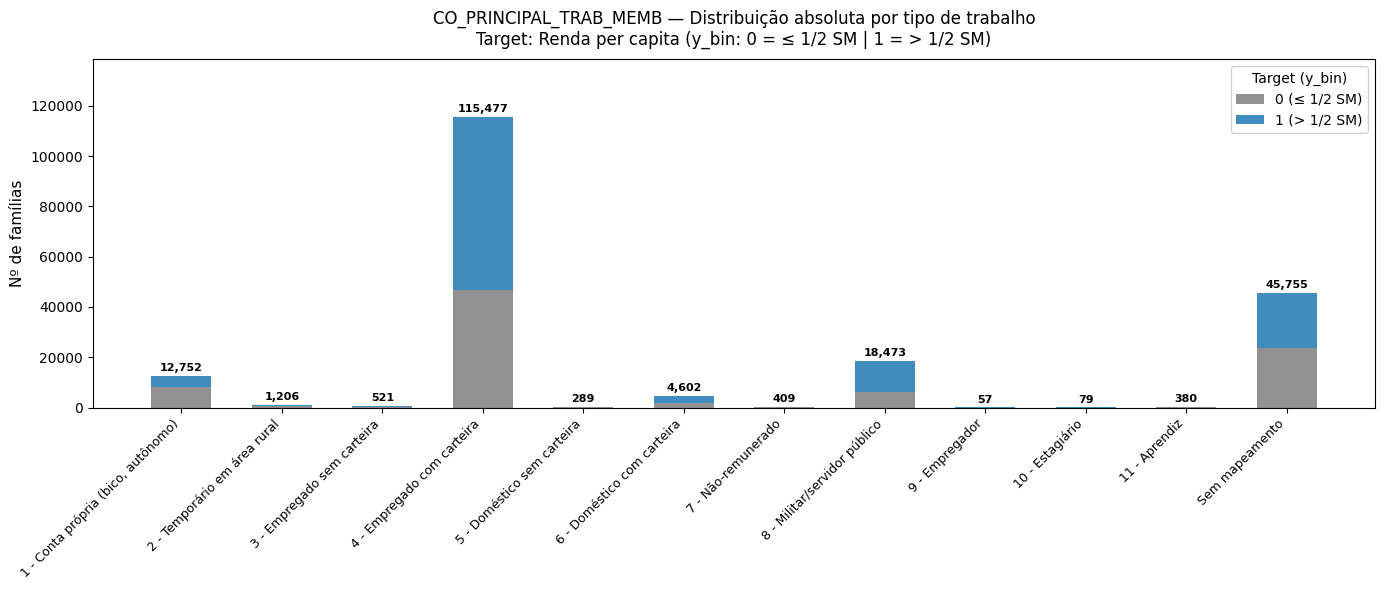

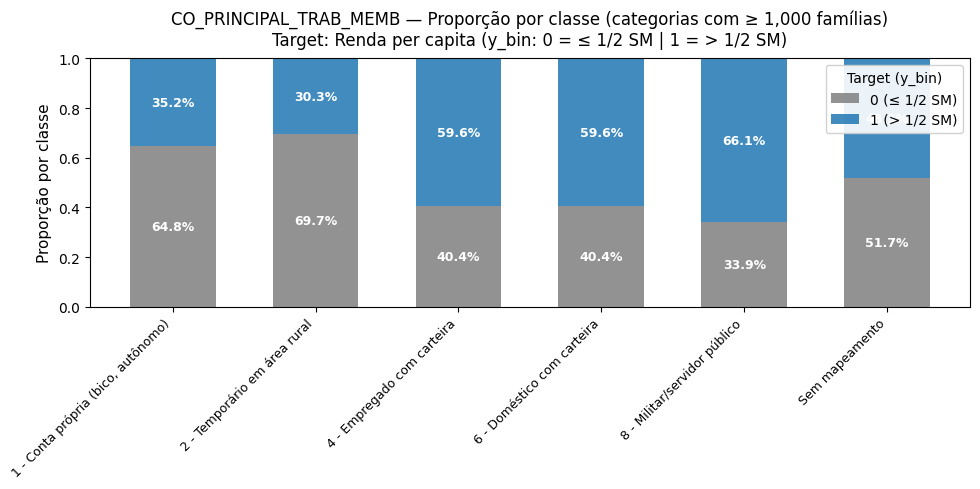


  CO_PRINCIPAL_TRAB_MEMB — Distribuição por tipo de trabalho
  (gráfico 2 filtra categorias com ≥ 1,000 famílias)


,Classe 0 (≤ 1/2 SM),Classe 1 (> 1/2 SM),Total,% Classe 1
rotulo,,,,
4 - Empregado com carteira,46705,68772,115477,59.6
Sem mapeamento,23677,22078,45755,48.3
8 - Militar/servidor público,6263,12210,18473,66.1
"1 - Conta própria (bico, autônomo)",8263,4489,12752,35.2
6 - Doméstico com carteira,1861,2741,4602,59.6
2 - Temporário em área rural,840,366,1206,30.3
3 - Empregado sem carteira,226,295,521,56.6
7 - Não-remunerado,284,125,409,30.6
11 - Aprendiz,237,143,380,37.6


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
col      = "CO_PRINCIPAL_TRAB_MEMB"
target   = "y_bin"
CLASSES  = [0, 1]
TOP_CAT  = 20
MIN_COUNT = 50
MIN_VOL_GRAFICO2 = 1000
AZUL       = "#1f77b4"
CINZA      = "#7f7f7f"
AZUL_ESCURO = "#0b2d5b"
TARGET_LABEL = "Renda per capita (y_bin: 0 = ≤ 1/2 SM | 1 = > 1/2 SM)"

# -----------------------------
# MAPEAMENTO
# -----------------------------
map_trab = {
    1:  "1 - Conta própria (bico, autônomo)",
    2:  "2 - Temporário em área rural",
    3:  "3 - Empregado sem carteira",
    4:  "4 - Empregado com carteira",
    5:  "5 - Doméstico sem carteira",
    6:  "6 - Doméstico com carteira",
    7:  "7 - Não-remunerado",
    8:  "8 - Militar/servidor público",
    9:  "9 - Empregador",
    10: "10 - Estagiário",
    11: "11 - Aprendiz",
}
CODIGOS_VALIDOS = set(map_trab.keys())

# -----------------------------
# DADOS
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test.values
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot["categoria_cod"] = df_plot[col]

df_plot.loc[
    ~df_plot["categoria_cod"].isin(CODIGOS_VALIDOS) &
    df_plot["categoria_cod"].notna(),
    "categoria_cod"
] = -2

def rotular(c):
    if pd.isna(c):
        return "Sem informação"
    c = int(c)
    if c == -2:
        return "Sem mapeamento"
    return map_trab.get(c, "Sem mapeamento")

df_plot["rotulo"] = df_plot["categoria_cod"].apply(rotular)

top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot["rotulo"].isin(top)].copy()

# -----------------------------
# TABELA BASE
# -----------------------------
tab = (
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)
prop   = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1)

def ordem_rotulo(r):
    if r.startswith("Sem mapeamento"): return 950
    if r == "Sem informação":          return 999
    try:    return int(str(r).split(" - ", 1)[0])
    except: return 998

ordem  = sorted(prop.index, key=ordem_rotulo)
prop   = prop.loc[ordem]
tab    = tab.loc[ordem]
counts = counts.loc[ordem]

cores    = {0: CINZA, 1: AZUL}
legendas = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
x_all    = np.arange(len(prop.index))

# ============================================================
# PLOT 1 — Volume absoluto (TODAS as categorias)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_all, tab[0].to_numpy(), width=0.6,
       color=CINZA, label="0 (≤ 1/2 SM)", alpha=0.85)
ax.bar(x_all, tab[1].to_numpy(), width=0.6,
       color=AZUL,  label="1 (> 1/2 SM)", alpha=0.85,
       bottom=tab[0].to_numpy())

for i, total in enumerate(counts):
    if total >= MIN_COUNT:
        ax.text(i, total + counts.max() * 0.01,
                f"{total:,.0f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

ax.set_ylim(0, counts.max() * 1.20)
ax.set_xticks(x_all)
ax.set_xticklabels(prop.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Nº de famílias", fontsize=11)
ax.set_title(
    f"{col} — Distribuição absoluta por tipo de trabalho\n"
    f"Target: {TARGET_LABEL}",
    fontsize=12, pad=10
)
ax.legend(          # ← ESTAVA FALTANDO
    title="Target (y_bin)",
    fontsize=10,
    title_fontsize=10,
    loc="upper right",
    bbox_to_anchor=(1, 1),
    framealpha=0.9
)
ax.grid(False)
plt.tight_layout()  # ← ESTAVA FALTANDO
plt.show()          # ← ESTAVA FALTANDO

# ============================================================
# PLOT 2 — Proporção por classe (apenas categorias com
#           volume >= MIN_VOL_GRAFICO2)
# ============================================================
mask_vol = counts >= MIN_VOL_GRAFICO2
prop_fil = prop.loc[mask_vol]
tab_fil  = tab.loc[mask_vol]
x_fil    = np.arange(len(prop_fil.index))
bottom   = np.zeros(len(prop_fil.index))

fig, ax = plt.subplots(figsize=(max(10, len(prop_fil) * 1.3), 5))
for k in CLASSES:
    vals = prop_fil[k].to_numpy()
    ax.bar(x_fil, vals, bottom=bottom, width=0.6,
           label=legendas[k], color=cores[k], alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(i, b + v / 2, f"{v:.1%}",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(x_fil)
ax.set_xticklabels(prop_fil.index, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Proporção por classe", fontsize=11)
ax.set_title(
    f"{col} — Proporção por classe (categorias com ≥ {MIN_VOL_GRAFICO2:,} famílias)\n"
    f"Target: {TARGET_LABEL}",
    fontsize=12, pad=10
)
ax.legend(
    title="Target (y_bin)",
    fontsize=10,
    title_fontsize=10,
    loc="upper right",
    bbox_to_anchor=(1, 1),  # ancora no canto superior direito
    framealpha=0.9           # fundo levemente transparente
)
ax.grid(False)
plt.tight_layout()
plt.show()



# ============================================================
# TABELA RESUMO
# ============================================================
df_resumo = tab.copy()
df_resumo.columns = ["Classe 0 (≤ 1/2 SM)", "Classe 1 (> 1/2 SM)"]
df_resumo["Total"]      = counts.values
df_resumo["% Classe 1"] = (tab[1] / counts * 100).round(1).values
df_resumo = df_resumo.sort_values("Total", ascending=False)

print(f"\n{'='*60}")
print(f"  {col} — Distribuição por tipo de trabalho")
print(f"  (gráfico 2 filtra categorias com ≥ {MIN_VOL_GRAFICO2:,} famílias)")
print(f"{'='*60}")
with pd.option_context("display.max_colwidth", 300):
    display(df_resumo)



## Análises adicionais considerando as classes de renda originais

In [59]:
THR = 0.80

df_test = df.loc[X_test.index, ["classe_renda"]].copy()

df_test["y_bin"] = y_test
df_test["proba_pos"] = pipeline_final.predict_proba(X_test)[:, 1]
df_test["y_pred_thr"] = (df_test["proba_pos"] >= THR).astype(int)

# flags de avaliação
df_test["TP"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==1)
df_test["FP"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==1)
df_test["FN"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==0)
df_test["TN"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==0)

df_test.head()



,classe_renda,y_bin,proba_pos,y_pred_thr,TP,FP,FN,TN
168694,2,1,0.556910,0,False,False,True,False
274079,2,1,0.270147,0,False,False,True,False
380349,2,1,0.925466,1,True,False,False,False
882683,2,1,0.346111,0,False,False,True,False
72408,2,1,0.391735,0,False,False,True,False


In [60]:
assert len(df_test) == len(X_test) == len(y_test)
df_test["classe_renda"].value_counts()


classe_renda
2    111417
1     62426
0     26157
Name: count, dtype: int64

### Distribuição de classe_renda por predição (convocados vs não)

In [61]:
tab = pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"], normalize="columns")
tab.columns = ["Não convocado (pred=0)", "Convocado (pred=1)"]
tab

,Não convocado (pred=0),Convocado (pred=1)
classe_renda,,
0,0.163981,0.016863
1,0.376672,0.090631
2,0.459347,0.892506


In [62]:
pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"])

y_pred_thr,0,1
classe_renda,,
0,25396,761
1,58336,4090
2,71140,40277


### Perfil do risco (proba) dentro de cada classe_renda

In [63]:
df_test.groupby("classe_renda")["proba_pos"].agg(
    media="mean",
    p25=lambda s: s.quantile(0.25),
    mediana="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90),
    n="size"
)

,media,p25,mediana,p75,p90,n
classe_renda,,,,,,
0,0.283143,0.067180,0.199904,0.472699,0.680894,26157
1,0.420091,0.196449,0.407749,0.635144,0.762672,62426
2,0.698201,0.586407,0.738263,0.849707,0.933982,111417


### Avaliação no subconjunto classe_renda == 0 (pobreza)

In [64]:
sub = df_test[df_test["classe_renda"] == 0]

res = {
    "thr": THR,
    "n": len(sub),
    "taxa_convocacao": sub["y_pred_thr"].mean(),
    "precision_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FP"].sum()) if (sub["TP"].sum() + sub["FP"].sum())>0 else np.nan,
    "recall_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FN"].sum()) if (sub["TP"].sum() + sub["FN"].sum())>0 else np.nan,
    "TP": int(sub["TP"].sum()),
    "FP": int(sub["FP"].sum()),
    "FN": int(sub["FN"].sum()),
    "TN": int(sub["TN"].sum()),
}
pd.Series(res)

thr                    0.800000
n                  26157.000000
taxa_convocacao        0.029094
precision_pos          0.000000
recall_pos                  NaN
TP                     0.000000
FP                   761.000000
FN                     0.000000
TN                 25396.000000
dtype: float64

### Perfil de classe_renda dentro dos Falsos Positivos (FP)

In [65]:
fp = df_test[df_test["FP"]]
fp["classe_renda"].value_counts(normalize=True).sort_index()


classe_renda
0    0.156875
1    0.843125
Name: proportion, dtype: float64

In [66]:
fp["classe_renda"].value_counts().sort_index()

classe_renda
0     761
1    4090
Name: count, dtype: int64

### Perfil dos Falsos Negativos (FN) dentro de classe_renda == 2

In [67]:
fn2 = df_test[(df_test["FN"]) & (df_test["classe_renda"] == 2)]
fn2.shape, fn2["proba_pos"].describe()

((71140, 8),
 count    71140.000000
 mean         0.589206
 std          0.174388
 min          0.003930
 25%          0.491017
 50%          0.638429
 75%          0.728321
 max          0.799996
 Name: proba_pos, dtype: float64)

In [68]:
tp2 = df_test[(df_test["TP"]) & (df_test["classe_renda"] == 2)]
pd.DataFrame({
    "FN_cl2_proba": fn2["proba_pos"].describe(),
    "TP_cl2_proba": tp2["proba_pos"].describe()
})

,FN_cl2_proba,TP_cl2_proba
count,71140.000000,40277.000000
mean,0.589206,0.890717
std,0.174388,0.058140
min,0.003930,0.800000
25%,0.491017,0.839829
50%,0.638429,0.883806
75%,0.728321,0.941883
max,0.799996,0.998502


### Sensibilidade ao threshold por classe_renda (0.75/0.80/0.85)

In [69]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    tmp = df_test.copy()
    tmp["pred"] = pred

    out = tmp.groupby("classe_renda")["pred"].mean().rename("taxa_convocacao").reset_index()
    out["threshold"] = t
    rows.append(out)

pd.concat(rows, ignore_index=True).pivot(index="classe_renda", columns="threshold", values="taxa_convocacao")

threshold,0.75,0.80,0.85
classe_renda,,,
0,0.055014,0.029094,0.012081
1,0.114119,0.065518,0.032134
2,0.474963,0.361498,0.249307


### “Precisão esperada” por threshold no grupo pobreza (classe 0)

In [70]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    sub = df_test[df_test["classe_renda"] == 0].copy()
    TP = ((sub["y_bin"]==1) & (pred[sub.index]==1)).sum()
    FP = ((sub["y_bin"]==0) & (pred[sub.index]==1)).sum()

    prec = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    conv = (pred[sub.index]==1).mean()

    rows.append({"threshold": t, "precision_pos_pobreza": prec, "taxa_convocacao_pobreza": conv})

pd.DataFrame(rows)


,threshold,precision_pos_pobreza,taxa_convocacao_pobreza
0,0.75,0.0,0.055014
1,0.80,0.0,0.029094
2,0.85,0.0,0.012081


### Criar grupos operacionais (classe_renda × convocação × risco)

In [71]:
df_test["faixa_risco"] = pd.cut(
    df_test["proba_pos"],
    bins=[-np.inf, 0.50, THR, np.inf],
    labels=["Baixo (<0.50)", f"Médio (0.50–{THR:.2f})", f"Alto (≥{THR:.2f})"]
)

tipologia = pd.crosstab(
    [df_test["classe_renda"], df_test["faixa_risco"]],
    df_test["y_pred_thr"],
    normalize="index"
)

tipologia.columns = ["Não convocado", "Convocado"]
tipologia

Não convocado  Convocado
classe_renda faixa_risco                                
0            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
1            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
2            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0

In [72]:
pd.crosstab([df_test["classe_renda"], df_test["faixa_risco"]], df_test["y_pred_thr"])

y_pred_thr                          0      1
classe_renda faixa_risco                    
0            Baixo (<0.50)      20124      0
             Médio (0.50–0.80)   5272      0
             Alto (≥0.80)           0    761
1            Baixo (<0.50)      37232      0
             Médio (0.50–0.80)  21104      0
             Alto (≥0.80)           0   4090
2            Baixo (<0.50)      18563      0
             Médio (0.50–0.80)  52577      0
             Alto (≥0.80)           0  40277

## Salvando o modelo final

In [73]:
import os
from pathlib import Path

# importa a classe para o pickle conseguir reconstruir o objeto
from models.xgb_threshold import XGBoostComThreshold

import joblib

PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'QTD_PESSOAS',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11'...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'IN_FREQUENTA_ESCOLA_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

In [74]:
from pathlib import Path

# garante que a classe custom existe como módulo importável (essencial p/ joblib depois)
from models.xgb_threshold import XGBoostComThreshold

# pasta padrão do projeto
DIR_MODELS = Path("models")
DIR_MODELS.mkdir(exist_ok=True)

# nome padronizado do arquivo do pipeline
MODEL_NAME = "pipeline_xgb_binario_thr080"
PATH_MODEL = DIR_MODELS / f"{MODEL_NAME}.joblib"

print("Modelo será salvo em:", PATH_MODEL)


Modelo será salvo em: models\pipeline_xgb_binario_thr080.joblib


In [75]:
import os
from pathlib import Path
import joblib
import pandas as pd


# importante: importar a classe custom antes do load
from models.xgb_threshold import XGBoostComThreshold

# carregar modelo já treinado
PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

# carregar base de aplicação
PATH_APLIC = Path("fam_pes_cad_11_25_amostra_aplicacao.csv")
df_app = pd.read_csv(PATH_APLIC)

# aplicar
proba = pipeline.predict_proba(df_app)[:, 1]
pred  = pipeline.predict(df_app)

df_out = df_app.copy()
df_out["PROB_RENDA_INFORMAL"] = proba
df_out["PRED_RENDA_INFORMAL"] = pred

df_out.to_csv("fam_pes_cad_11_25_resultado_ml.csv", index=False)
print("✅ Salvo:", "fam_pes_cad_11_25_resultado_ml.csv")


✅ Salvo: fam_pes_cad_11_25_resultado_ml.csv
